# yelp-review-sentiment-analysis

In [3]:
%matplotlib inline
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, BayesianRidge, ElasticNetCV, ElasticNet
from dmba import regressionSummary, exhaustive_search, liftChart, gainsChart
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, ENGLISH_STOP_WORDS
#from sklearn.feature_extraction.text import TfidfTransformer
#from sklearn.feature_extraction.stop_words import ENGLISH_STOP_WORDS
#from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction import _stop_words
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
import nltk
from nltk import word_tokenize          
from nltk.stem.snowball import EnglishStemmer 
from nltk.corpus import stopwords
import matplotlib.pylab as plt
from dmba import printTermDocumentMatrix, classificationSummary, liftChart
from sklearn.decomposition import LatentDirichletAllocation
from nltk.stem.snowball import EnglishStemmer 
#from tensorflow import keras
#from typing import List
#from tensorflow.keras.preprocessing.text import Tokenizer
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marvi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Data Scraping

### Elk Grove Data Scraping

In [3]:
import json
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

def process_yelp_json():
    # 1. Create a hidden root window for the file prompt
    root = tk.Tk()
    root.withdraw()

    # 2. Open file browser prompt
    file_path = filedialog.askopenfilename(
        title="Select Yelp JSON File",
        filetypes=[("JSON files", "*.json"), ("All files", "*.*")]
    )

    if not file_path:
        print("No file selected. Exiting.")
        return

    try:
        # 3. Load and parse the JSON data
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        all_biz_data = []
        entries = data.get('log', {}).get('entries', [])

        for entry in entries:
            content_text = entry.get('response', {}).get('content', {}).get('text', '{}')
            content_json = json.loads(content_text)
            
            # Navigate to the business components list
            components = content_json.get('searchPageProps', {}).get('mainContentComponentsListProps', [])
            
            for comp in components:
                if 'searchResultBusiness' in comp:
                    biz = comp['searchResultBusiness']
                    
                    # Extract Category titles
                    categories = ", ".join([c.get('title') for c in biz.get('categories', [])])
                    
                    # Extract Highlights
                    highlights_data = comp.get('searchResultBusinessHighlights', {})
                    highlights = "N/A"
                    if highlights_data and 'businessHighlights' in highlights_data:
                        highlights = ", ".join([h.get('title') for h in highlights_data['businessHighlights']])
                    
                    # Extract DoorDash link from searchActions
                    doordash_link = "N/A"
                    for action in comp.get('searchActions', []):
                        attrs = action.get('buttonProps', {}).get('attributes', {})
                        if attrs and 'linkoutUrl' in attrs:
                            doordash_link = attrs['linkoutUrl']
                            break

                    all_biz_data.append({
                        "bizId": comp.get('bizId'),
                        "Name": biz.get('name'),
                        "Rating": biz.get('rating'),
                        "Reviews": biz.get('reviewCount'),
                        "Price": biz.get('priceRange', "N/A"),
                        "Phone": biz.get('phone', "N/A"),
                        "Categories": categories,
                        "Highlights": highlights,
                        "Order Link": doordash_link
                    })

        # 4. Clean and Save Data
        if not all_biz_data:
            messagebox.showwarning("No Data", "No business information found in the selected file.")
            return

        # Convert to DataFrame and remove duplicates
        df = pd.DataFrame(all_biz_data).drop_duplicates(subset=['bizId'])

        # Prompt user for save location
        save_path = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv")],
            initialfile="elk_grove_results.csv"
        )

        if save_path:
            df.to_csv(save_path, index=False)
            messagebox.showinfo("Success", f"Data saved successfully to:\n{save_path}")
            print(f"File saved to {save_path}")

    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_yelp_json()

File saved to H:/MSBA 212/Group Project/elk_grove_results.csv


### Elk Grove Yelp Data Review Scraping

In [4]:
"""
Yelp Review Scraper — Python Standard Library Only
===================================================
Extracts restaurant reviews from Yelp.com using only built-in modules.
No Selenium, BeautifulSoup, requests, or any pip packages required.

How it works:
  Yelp pages are protected by Cloudflare's JS challenge, so we can't
  fetch the HTML directly with urllib. Instead we resolve the business
  ID through one of three methods, then hit Yelp's internal GraphQL
  endpoint (which is NOT behind Cloudflare) to download full reviews.

  Business ID resolution methods (in order of preference):
    A) Yelp Fusion API key  — fully automatic, free signup at
       https://fusion.yelp.com (set YELP_API_KEY env var)
    B) Saved HTML file       — save the page from your browser once,
       pass --html <file>
    C) Direct ID             — pass --biz-id <encBizId> if you already
       know it (visible in DevTools Network tab as "encBizId")

Usage examples:
  # Interactive mode — prompt for business ID (easiest)
  python yelp_review_scraper.py

  # CLI with API key
  set YELP_API_KEY=your_key_here
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50

  # CLI from saved HTML
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --html page.html

  # CLI with known business ID
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --biz-id WavvLdfdP6g8aZTtbBQHTw
"""

import urllib.request
import urllib.parse
import http.cookiejar
import json
import re
import base64
import ssl
import csv
import sys
import os
import time

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

GRAPHQL_ENDPOINT = "https://www.yelp.com/gql/batch"
YELP_FUSION_API = "https://api.yelp.com/v3/businesses"
DOCUMENT_ID = "ef51f33d1b0eccc958dddbf6cde15739c48b34637a00ebe316441031d4bf7681"
REVIEWS_PER_PAGE = 10

USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/125.0.0.0 Safari/537.36"
)

GQL_HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
    "Content-Type": "application/json",
    "Origin": "https://www.yelp.com",
    "x-apollo-operation-name": "GetBusinessReviewFeed",
}

REQUEST_DELAY = 1.5  # seconds between paginated requests


# ---------------------------------------------------------------------------
# HTTP helpers
# ---------------------------------------------------------------------------

def _create_opener():
    """Build a urllib opener that stores cookies across requests."""
    cj = http.cookiejar.CookieJar()
    ctx = ssl.create_default_context()
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ctx),
        urllib.request.HTTPCookieProcessor(cj),
    )
    return opener


_opener = _create_opener()


def _fetch(url, data=None, headers=None, method="GET"):
    """Fetch a URL with the shared opener (keeps cookies). Returns str."""
    req = urllib.request.Request(url, data=data, headers=headers or {}, method=method)
    resp = _opener.open(req, timeout=30)
    raw = resp.read()
    if resp.headers.get("Content-Encoding", "") == "gzip":
        import gzip
        raw = gzip.decompress(raw)
    return raw.decode("utf-8")


# ---------------------------------------------------------------------------
# Business ID resolution — three methods
# ---------------------------------------------------------------------------

def _alias_from_url(yelp_url):
    """Extract the business alias (slug) from a Yelp URL."""
    m = re.search(r"/biz/([^?#/]+)", yelp_url)
    if not m:
        raise ValueError(f"Cannot extract business alias from URL: {yelp_url}")
    return m.group(1)


def resolve_id_via_api(yelp_url, api_key):
    """
    Method A: Use the free Yelp Fusion API to look up the business.
    Returns the encBizId.
    """
    alias = _alias_from_url(yelp_url)
    url = f"{YELP_FUSION_API}/{urllib.parse.quote(alias, safe='')}"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",
    }
    print(f"[1/3] Resolving business ID via Yelp Fusion API ...")
    raw = _fetch(url, headers=headers)
    data = json.loads(raw)
    biz_id = data["id"]
    name = data.get("name", alias)
    print(f"      Business: {name}")
    print(f"      ID:       {biz_id}")
    return biz_id


def resolve_id_from_html(html_path):
    """
    Method B: Extract encBizId from a locally saved Yelp HTML file.
    """
    print(f"[1/3] Extracting business ID from saved HTML: {html_path}")
    with open(html_path, "r", encoding="utf-8", errors="replace") as f:
        html = f.read()

    for pattern in [
        r'<meta\s+name="yelp-biz-id"\s+content="([^"]+)"',
        r'<meta\s+content="([^"]+)"\s+name="yelp-biz-id"',
        r'"bizId"\s*:\s*"([^"]+)"',
        r'"encBizId"\s*:\s*"([^"]+)"',
        r'data-biz-id="([^"]+)"',
    ]:
        m = re.search(pattern, html)
        if m:
            biz_id = m.group(1)
            print(f"      Business ID: {biz_id}")
            return biz_id

    raise ValueError(
        "Could not find the business ID in the HTML file. "
        "Make sure you saved the full page source from a Yelp business page."
    )


# ---------------------------------------------------------------------------
# GraphQL review fetching
# ---------------------------------------------------------------------------

def _encode_cursor(offset):
    """Build a base64-encoded pagination cursor."""
    obj = {"version": 1, "type": "offset", "offset": offset}
    return base64.b64encode(json.dumps(obj).encode()).decode()


def _build_payload(biz_id, offset=0):
    """Construct the JSON body for GetBusinessReviewFeed."""
    return json.dumps([{
        "operationName": "GetBusinessReviewFeed",
        "variables": {
            "encBizId": biz_id,
            "reviewsPerPage": REVIEWS_PER_PAGE,
            "selectedReviewEncId": "",
            "hasSelectedReview": False,
            "sortBy": "DATE_DESC",
            "languageCode": "en",
            "ratings": [5, 4, 3, 2, 1],
            "after": _encode_cursor(offset) if offset > 0 else None,
            "isSearching": False,
            "isTranslating": False,
            "translateLanguageCode": "en",
            "reactionsSourceFlow": "businessPageReviewSection",
            "minConfidenceLevel": "HIGH_CONFIDENCE",
            "highlightType": "",
            "highlightIdentifier": "",
            "isHighlighting": False,
        },
        "extensions": {
            "operationType": "query",
            "documentId": DOCUMENT_ID,
        },
    }]).encode("utf-8")


def fetch_reviews_page(biz_id, referer_url, offset=0):
    """POST one page of reviews from the GraphQL endpoint."""
    headers = dict(GQL_HEADERS)
    headers["Referer"] = referer_url
    raw = _fetch(GRAPHQL_ENDPOINT, data=_build_payload(biz_id, offset),
                 headers=headers, method="POST")
    return json.loads(raw)


def parse_reviews(response_json):
    """Extract review dicts from the GraphQL batch response."""
    reviews = []
    try:
        edges = (
            response_json[0]
            .get("data", {})
            .get("business", {})
            .get("reviews", {})
            .get("edges", [])
        )
    except (IndexError, KeyError, TypeError):
        return reviews

    def _get_count(obj, *keys):
        for k in keys:
            v = obj.get(k)
            if v is not None:
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return v if isinstance(v, (int, float)) else 0
        return 0

    for edge in edges:
        node = edge.get("node", {})
        author = node.get("author", {}) or {}
        text_obj = node.get("text", {}) or {}
        feedback = node.get("feedback", {}) or {}
        created = node.get("createdAt", {}) or {}

        # Parse date: prefer localDateTime, fall back to utcDateTime
        raw_dt = created.get("localDateTime") or created.get("utcDateTime", "")
        date_str = raw_dt[:10] if raw_dt else ""  # "2026-02-01"

        # Legacy counts from feedback object
        useful = _get_count(feedback, "usefulCount", "useful")
        funny = _get_count(feedback, "funnyCount", "funny")
        cool = _get_count(feedback, "coolCount", "cool")

        # New reaction counts from availableReactionsContainer (reactionType -> count)
        reactions_map = {}
        reactions_container = node.get("availableReactionsContainer", {}) or {}
        for r in reactions_container.get("availableReactions", []):
            rtype = r.get("reactionType")
            if rtype:
                try:
                    reactions_map[rtype] = int(r.get("count", 0))
                except (ValueError, TypeError):
                    reactions_map[rtype] = 0

        helpful = reactions_map.get("HELPFUL", 0) or useful  # fallback: Useful = Helpful
        thanks = reactions_map.get("THANKS", 0)
        love_this = reactions_map.get("LOVE_THIS", 0)
        oh_no = reactions_map.get("OH_NO", 0)
        what_do_you_think = reactions_map.get("WHAT_DO_YOU_THINK", 0)  # if it exists

        reviews.append({
            "author_name": author.get("displayName", ""),
            "author_location": author.get("displayLocation", ""),
            "rating": node.get("rating", ""),
            "date": date_str,
            "text": text_obj.get("full", ""),
            "language": text_obj.get("language", ""),
            "useful": useful,
            "funny": funny,
            "cool": cool,
            "helpful": helpful,
            "thanks": thanks,
            "love_this": love_this,
            "oh_no": oh_no,
            "what_do_you_think": what_do_you_think,
        })

    return reviews


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def scrape_yelp_reviews(biz_id, yelp_url, num_reviews=10, debug=False):
    """
    Download up to `num_reviews` reviews for the given business.
    Returns a list of review dicts.
    If debug=True, saves raw API response to yelp_debug_response.json for inspection.
    """
    all_reviews = []
    offset = 0
    page = 1

    print(f"[2/3] Fetching reviews (target: {num_reviews}) ...")

    while len(all_reviews) < num_reviews:
        print(f"      Page {page} (offset {offset}) ...", end=" ", flush=True)

        try:
            resp = fetch_reviews_page(biz_id, yelp_url, offset)
        except urllib.error.HTTPError as e:
            body = e.read().decode("utf-8", errors="replace")
            print(f"HTTP {e.code}")
            if "captcha" in body.lower() or "cloudflare" in body.lower():
                print("      Rate limited by Cloudflare. Try again later.")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        if debug and page == 1:
            with open("yelp_debug_response.json", "w", encoding="utf-8") as f:
                json.dump(resp, f, indent=2, ensure_ascii=False)
            print(f"\n      [DEBUG] Raw API response saved to yelp_debug_response.json")
            print(f"      Check the 'feedback' object in each review node for available reaction fields.\n")

        page_reviews = parse_reviews(resp)
        print(f"got {len(page_reviews)} reviews")

        if not page_reviews:
            print("      No more reviews available.")
            break

        all_reviews.extend(page_reviews)
        offset += REVIEWS_PER_PAGE
        page += 1

        if len(all_reviews) >= num_reviews:
            break

        time.sleep(REQUEST_DELAY)

    all_reviews = all_reviews[:num_reviews]
    print(f"      Total collected: {len(all_reviews)} reviews")
    return all_reviews


# ---------------------------------------------------------------------------
# CSV output
# ---------------------------------------------------------------------------

FIELDNAMES = [
    "biz_id", "biz_name",
    "author_name", "author_location", "rating",
    "date", "text", "language",
    "useful", "funny", "cool", "helpful", "thanks", "love_this",
    "oh_no", "what_do_you_think",
]


def save_to_csv(reviews, filename="yelp_reviews.csv"):
    """Write reviews to a CSV file."""
    if not reviews:
        print("No reviews to save.")
        return
    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES)
        w.writeheader()
        w.writerows(reviews)
    print(f"[3/3] Saved {len(reviews)} reviews to {filename}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def _print_usage():
    print(
        "Yelp Review Scraper (stdlib-only)\n"
        "\n"
        "Interactive mode (default):\n"
        "  python yelp_review_scraper.py\n"
        "  → Prompts for business ID and number of reviews.\n"
        "\n"
        "CLI mode:\n"
        '  python yelp_review_scraper.py <yelp_url> [num_reviews] [options]\n'
        "\n"
        "Options:\n"
        "  --biz-id ID     Provide the encBizId directly\n"
        "  --html FILE     Extract biz-id from a saved HTML file\n"
        "  --api-key KEY   Yelp Fusion API key (or set YELP_API_KEY env var)\n"
        "  --debug         Save raw API response to yelp_debug_response.json\n"
        "\n"
        "Business ID: Find in browser DevTools (Network tab, search for 'encBizId') or\n"
        "in a saved Yelp page source. Example: WavvLdfdP6g8aZTtbBQHTw\n"
    )


def _read_all_businesses(csv_path="elk_grove_results.csv"):
    """Read all bizId/Name pairs from yelp_results.csv."""
    businesses = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            biz_id = (row.get("bizId") or "").strip()
            biz_name = (row.get("Name") or "unknown").strip()
            raw_reviews = (row.get("Reviews") or "").strip()
            try:
                total_reviews = int(raw_reviews.replace(",", ""))
            except (ValueError, TypeError, AttributeError):
                total_reviews = 10
            if biz_id:
                businesses.append((biz_id, biz_name, total_reviews))
    return businesses

# Slightly modified to account for changes

def _run_interactive():
    """Walk through every bizId in yelp_results.csv, prompt y/n, aggregate into one CSV."""
    print("Yelp Review Scraper — Batch Mode\n")


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


    csv_path = os.path.join(script_dir, "elk_grove_results.csv")
    if not os.path.exists(csv_path):
        alt = "/mnt/data/elk_grove_results.csv"
        if os.path.exists(alt):
            csv_path = alt


    businesses = _read_all_businesses(csv_path)

    if not businesses:
        print("Error: No business IDs found in yelp_results.csv")
        sys.exit(1)

    print(f"Found {len(businesses)} businesses in yelp_results.csv\n")

    all_reviews = []       # aggregated reviews across all businesses
    scraped_count = 0
    referer_url = "https://www.yelp.com/"
    output_file = "elk_grove_yelp_reviews.csv"


    for idx, (biz_id, biz_name, total) in enumerate(businesses, start=1):
        print(f"--- [{idx}/{len(businesses)}] {biz_name} ({biz_id}) ---")
        answer = input(f"  Scrape reviews for '{biz_name}'? (y/n/quit): ").strip().lower()

        if answer in ("q", "quit", "stop"):
            print("  Stopping.\n")
            break
        if answer not in ("y", "yes"):
            print("  Skipped.\n")
            continue

        print(f"  Fetching up to {total} reviews ...")  
        try:
            reviews = scrape_yelp_reviews(biz_id, referer_url, num_reviews=total)  
        except Exception as e:
            print(f"  Error scraping {biz_name}: {e}\n")
            continue

        # Tag each review with the business it belongs to
        for r in reviews:
            r["biz_id"] = biz_id
            r["biz_name"] = biz_name

        all_reviews.extend(reviews)
        scraped_count += 1
        print(f"  Got {len(reviews)} reviews (running total: {len(all_reviews)})\n")

        # Check if this was the last business
        if idx == len(businesses):
            print("Reached the end of yelp_results.csv.\n")
            break

        time.sleep(REQUEST_DELAY)

    # Save aggregated CSV
    save_to_csv(all_reviews, output_file)
    print(f"\nDone! Scraped {scraped_count} businesses, {len(all_reviews)} total reviews.")
    print(f"Output: {output_file}")

def _looks_like_yelp_url(s: str) -> bool:
    if not s:
        return False
    return ("yelp.com/" in s) and ("/biz/" in s)

def _strip_notebook_argv(args):
    if not args:
        return []
    for a in args:
        if _looks_like_yelp_url(a):
            return args
    return []
# -----------------------------------------------


def main():
    args = sys.argv[1:]
    args = _strip_notebook_argv(args) 

    if args and args[0] in ("-h", "--help"):
        _print_usage()
        sys.exit(0)

    # Interactive mode: no arguments → prompt for business ID
    if not args:
        _run_interactive()
        return

    # CLI mode
    url = args[0]
    num_reviews = 10
    biz_id = None
    html_file = None
    api_key = os.environ.get("YELP_API_KEY", "")
    debug = False

    i = 1
    while i < len(args):
        if args[i] == "--biz-id" and i + 1 < len(args):
            biz_id = args[i + 1]
            i += 2
        elif args[i] == "--html" and i + 1 < len(args):
            html_file = args[i + 1]
            i += 2
        elif args[i] == "--api-key" and i + 1 < len(args):
            api_key = args[i + 1]
            i += 2
        elif args[i] == "--debug":
            debug = True
            i += 1
        elif args[i].isdigit():
            num_reviews = int(args[i])
            i += 1
        else:
            i += 1

    # Validate URL
    if "yelp.com/biz/" not in url:
        print("Error: URL must be a Yelp business page (contains 'yelp.com/biz/').")
        sys.exit(1)

    # Resolve business ID
    if biz_id:
        print(f"[1/3] Using provided business ID: {biz_id}")
    elif html_file:
        biz_id = resolve_id_from_html(html_file)
    elif api_key:
        biz_id = resolve_id_via_api(url, api_key)
    else:
        print(
            "ERROR: Cannot resolve business ID.\n"
            "\n"
            "Yelp pages are protected by Cloudflare, so urllib cannot fetch\n"
            "the HTML directly. Use one of these methods:\n"
            "\n"
            "  1. Set YELP_API_KEY env var (free: https://fusion.yelp.com)\n"
            "     set YELP_API_KEY=your_key_here\n"
            "\n"
            "  2. Save the Yelp page from your browser (Ctrl+U, Ctrl+S)\n"
            "     then pass: --html saved_page.html\n"
            "\n"
            "  3. Copy the business ID from browser DevTools (Network tab,\n"
            '     search for "encBizId" in any XHR request)\n'
            "     then pass: --biz-id THE_ID\n"
        )
        sys.exit(1)

    # Scrape reviews
    reviews = scrape_yelp_reviews(biz_id, url, num_reviews=num_reviews, debug=debug)

    # Save to CSV
    slug_match = re.search(r"/biz/([^?#/]+)", url)
    slug = slug_match.group(1) if slug_match else "yelp"
    output_file = f"{slug}_reviews.csv"
    save_to_csv(reviews, output_file)

    # Print sample
    if reviews:
        print(f"\n--- Sample Review (1 of {len(reviews)}) ---")
        r = reviews[0]
        rating = r.get("rating", 0)
        stars = "*" * int(rating) if isinstance(rating, (int, float)) else str(rating)
        print(f"  Author : {r['author_name']} ({r['author_location']})")
        print(f"  Rating : {stars} ({rating}/5)")
        print(f"  Date   : {r['date']}")
        text = r["text"]
        print(f"  Text   : {text[:200]}{'...' if len(text) > 200 else ''}")


if __name__ == "__main__":
    main()

Yelp Review Scraper — Batch Mode

Found 11 businesses in yelp_results.csv

--- [1/11] ExtraMile (2pMaC6eOAAyiiRqef8bmZw) ---
  Scrape reviews for 'ExtraMile'? (y/n/quit): y
  Fetching up to 0 reviews ...
[2/3] Fetching reviews (target: 0) ...
      Total collected: 0 reviews
  Got 0 reviews (running total: 0)

--- [2/11] Rocket (ubjPGH2kzWnEuHiG7pMh6A) ---
  Scrape reviews for 'Rocket'? (y/n/quit): y
  Fetching up to 3 reviews ...
[2/3] Fetching reviews (target: 3) ...
      Page 1 (offset 0) ... got 3 reviews
      Total collected: 3 reviews
  Got 3 reviews (running total: 3)

--- [3/11] Wilton Store (ydaQDodgsfUvxhS9bMlssg) ---
  Scrape reviews for 'Wilton Store'? (y/n/quit): y
  Fetching up to 7 reviews ...
[2/3] Fetching reviews (target: 7) ...
      Page 1 (offset 0) ... got 7 reviews
      Total collected: 7 reviews
  Got 7 reviews (running total: 10)

--- [4/11] Power Market (4wj0QBV9ksubZ9e-gWx9Qw) ---
  Scrape reviews for 'Power Market'? (y/n/quit): y
  Fetching up to 7 review

### Arden Data Scraping

In [5]:
import json
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

def process_yelp_json():
    # 1. Create a hidden root window for the file prompt
    root = tk.Tk()
    root.withdraw()

    # 2. Open file browser prompt
    file_path = filedialog.askopenfilename(
        title="Select Yelp JSON File",
        filetypes=[("JSON files", "*.json"), ("All files", "*.*")]
    )

    if not file_path:
        print("No file selected. Exiting.")
        return

    try:
        # 3. Load and parse the JSON data
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        all_biz_data = []
        entries = data.get('log', {}).get('entries', [])

        for entry in entries:
            content_text = entry.get('response', {}).get('content', {}).get('text', '{}')
            content_json = json.loads(content_text)
            
            # Navigate to the business components list
            components = content_json.get('searchPageProps', {}).get('mainContentComponentsListProps', [])
            
            for comp in components:
                if 'searchResultBusiness' in comp:
                    biz = comp['searchResultBusiness']
                    
                    # Extract Category titles
                    categories = ", ".join([c.get('title') for c in biz.get('categories', [])])
                    
                    # Extract Highlights
                    highlights_data = comp.get('searchResultBusinessHighlights', {})
                    highlights = "N/A"
                    if highlights_data and 'businessHighlights' in highlights_data:
                        highlights = ", ".join([h.get('title') for h in highlights_data['businessHighlights']])
                    
                    # Extract DoorDash link from searchActions
                    doordash_link = "N/A"
                    for action in comp.get('searchActions', []):
                        attrs = action.get('buttonProps', {}).get('attributes', {})
                        if attrs and 'linkoutUrl' in attrs:
                            doordash_link = attrs['linkoutUrl']
                            break

                    all_biz_data.append({
                        "bizId": comp.get('bizId'),
                        "Name": biz.get('name'),
                        "Rating": biz.get('rating'),
                        "Reviews": biz.get('reviewCount'),
                        "Price": biz.get('priceRange', "N/A"),
                        "Phone": biz.get('phone', "N/A"),
                        "Categories": categories,
                        "Highlights": highlights,
                        "Order Link": doordash_link
                    })

        # 4. Clean and Save Data
        if not all_biz_data:
            messagebox.showwarning("No Data", "No business information found in the selected file.")
            return

        # Convert to DataFrame and remove duplicates
        df = pd.DataFrame(all_biz_data).drop_duplicates(subset=['bizId'])

        # Prompt user for save location
        save_path = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv")],
            initialfile="arden_results.csv"
        )

        if save_path:
            df.to_csv(save_path, index=False)
            messagebox.showinfo("Success", f"Data saved successfully to:\n{save_path}")
            print(f"File saved to {save_path}")

    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_yelp_json()

File saved to H:/MSBA 212/Group Project/arden_results.csv


### Arden Yelp Data Review Scraping

In [7]:
"""
Yelp Review Scraper — Python Standard Library Only
===================================================
Extracts restaurant reviews from Yelp.com using only built-in modules.
No Selenium, BeautifulSoup, requests, or any pip packages required.

How it works:
  Yelp pages are protected by Cloudflare's JS challenge, so we can't
  fetch the HTML directly with urllib. Instead we resolve the business
  ID through one of three methods, then hit Yelp's internal GraphQL
  endpoint (which is NOT behind Cloudflare) to download full reviews.

  Business ID resolution methods (in order of preference):
    A) Yelp Fusion API key  — fully automatic, free signup at
       https://fusion.yelp.com (set YELP_API_KEY env var)
    B) Saved HTML file       — save the page from your browser once,
       pass --html <file>
    C) Direct ID             — pass --biz-id <encBizId> if you already
       know it (visible in DevTools Network tab as "encBizId")

Usage examples:
  # Interactive mode — prompt for business ID (easiest)
  python yelp_review_scraper.py

  # CLI with API key
  set YELP_API_KEY=your_key_here
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50

  # CLI from saved HTML
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --html page.html

  # CLI with known business ID
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --biz-id WavvLdfdP6g8aZTtbBQHTw
"""

import urllib.request
import urllib.parse
import http.cookiejar
import json
import re
import base64
import ssl
import csv
import sys
import os
import time

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

GRAPHQL_ENDPOINT = "https://www.yelp.com/gql/batch"
YELP_FUSION_API = "https://api.yelp.com/v3/businesses"
DOCUMENT_ID = "ef51f33d1b0eccc958dddbf6cde15739c48b34637a00ebe316441031d4bf7681"
REVIEWS_PER_PAGE = 10

USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/125.0.0.0 Safari/537.36"
)

GQL_HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
    "Content-Type": "application/json",
    "Origin": "https://www.yelp.com",
    "x-apollo-operation-name": "GetBusinessReviewFeed",
}

REQUEST_DELAY = 1.5  # seconds between paginated requests


# ---------------------------------------------------------------------------
# HTTP helpers
# ---------------------------------------------------------------------------

def _create_opener():
    """Build a urllib opener that stores cookies across requests."""
    cj = http.cookiejar.CookieJar()
    ctx = ssl.create_default_context()
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ctx),
        urllib.request.HTTPCookieProcessor(cj),
    )
    return opener


_opener = _create_opener()


def _fetch(url, data=None, headers=None, method="GET"):
    """Fetch a URL with the shared opener (keeps cookies). Returns str."""
    req = urllib.request.Request(url, data=data, headers=headers or {}, method=method)
    resp = _opener.open(req, timeout=30)
    raw = resp.read()
    if resp.headers.get("Content-Encoding", "") == "gzip":
        import gzip
        raw = gzip.decompress(raw)
    return raw.decode("utf-8")


# ---------------------------------------------------------------------------
# Business ID resolution — three methods
# ---------------------------------------------------------------------------

def _alias_from_url(yelp_url):
    """Extract the business alias (slug) from a Yelp URL."""
    m = re.search(r"/biz/([^?#/]+)", yelp_url)
    if not m:
        raise ValueError(f"Cannot extract business alias from URL: {yelp_url}")
    return m.group(1)


def resolve_id_via_api(yelp_url, api_key):
    """
    Method A: Use the free Yelp Fusion API to look up the business.
    Returns the encBizId.
    """
    alias = _alias_from_url(yelp_url)
    url = f"{YELP_FUSION_API}/{urllib.parse.quote(alias, safe='')}"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",
    }
    print(f"[1/3] Resolving business ID via Yelp Fusion API ...")
    raw = _fetch(url, headers=headers)
    data = json.loads(raw)
    biz_id = data["id"]
    name = data.get("name", alias)
    print(f"      Business: {name}")
    print(f"      ID:       {biz_id}")
    return biz_id


def resolve_id_from_html(html_path):
    """
    Method B: Extract encBizId from a locally saved Yelp HTML file.
    """
    print(f"[1/3] Extracting business ID from saved HTML: {html_path}")
    with open(html_path, "r", encoding="utf-8", errors="replace") as f:
        html = f.read()

    for pattern in [
        r'<meta\s+name="yelp-biz-id"\s+content="([^"]+)"',
        r'<meta\s+content="([^"]+)"\s+name="yelp-biz-id"',
        r'"bizId"\s*:\s*"([^"]+)"',
        r'"encBizId"\s*:\s*"([^"]+)"',
        r'data-biz-id="([^"]+)"',
    ]:
        m = re.search(pattern, html)
        if m:
            biz_id = m.group(1)
            print(f"      Business ID: {biz_id}")
            return biz_id

    raise ValueError(
        "Could not find the business ID in the HTML file. "
        "Make sure you saved the full page source from a Yelp business page."
    )


# ---------------------------------------------------------------------------
# GraphQL review fetching
# ---------------------------------------------------------------------------

def _encode_cursor(offset):
    """Build a base64-encoded pagination cursor."""
    obj = {"version": 1, "type": "offset", "offset": offset}
    return base64.b64encode(json.dumps(obj).encode()).decode()


def _build_payload(biz_id, offset=0):
    """Construct the JSON body for GetBusinessReviewFeed."""
    return json.dumps([{
        "operationName": "GetBusinessReviewFeed",
        "variables": {
            "encBizId": biz_id,
            "reviewsPerPage": REVIEWS_PER_PAGE,
            "selectedReviewEncId": "",
            "hasSelectedReview": False,
            "sortBy": "DATE_DESC",
            "languageCode": "en",
            "ratings": [5, 4, 3, 2, 1],
            "after": _encode_cursor(offset) if offset > 0 else None,
            "isSearching": False,
            "isTranslating": False,
            "translateLanguageCode": "en",
            "reactionsSourceFlow": "businessPageReviewSection",
            "minConfidenceLevel": "HIGH_CONFIDENCE",
            "highlightType": "",
            "highlightIdentifier": "",
            "isHighlighting": False,
        },
        "extensions": {
            "operationType": "query",
            "documentId": DOCUMENT_ID,
        },
    }]).encode("utf-8")


def fetch_reviews_page(biz_id, referer_url, offset=0):
    """POST one page of reviews from the GraphQL endpoint."""
    headers = dict(GQL_HEADERS)
    headers["Referer"] = referer_url
    raw = _fetch(GRAPHQL_ENDPOINT, data=_build_payload(biz_id, offset),
                 headers=headers, method="POST")
    return json.loads(raw)


def parse_reviews(response_json):
    """Extract review dicts from the GraphQL batch response."""
    reviews = []
    try:
        edges = (
            response_json[0]
            .get("data", {})
            .get("business", {})
            .get("reviews", {})
            .get("edges", [])
        )
    except (IndexError, KeyError, TypeError):
        return reviews

    def _get_count(obj, *keys):
        for k in keys:
            v = obj.get(k)
            if v is not None:
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return v if isinstance(v, (int, float)) else 0
        return 0

    for edge in edges:
        node = edge.get("node", {})
        author = node.get("author", {}) or {}
        text_obj = node.get("text", {}) or {}
        feedback = node.get("feedback", {}) or {}
        created = node.get("createdAt", {}) or {}

        # Parse date: prefer localDateTime, fall back to utcDateTime
        raw_dt = created.get("localDateTime") or created.get("utcDateTime", "")
        date_str = raw_dt[:10] if raw_dt else ""  # "2026-02-01"

        # Legacy counts from feedback object
        useful = _get_count(feedback, "usefulCount", "useful")
        funny = _get_count(feedback, "funnyCount", "funny")
        cool = _get_count(feedback, "coolCount", "cool")

        # New reaction counts from availableReactionsContainer (reactionType -> count)
        reactions_map = {}
        reactions_container = node.get("availableReactionsContainer", {}) or {}
        for r in reactions_container.get("availableReactions", []):
            rtype = r.get("reactionType")
            if rtype:
                try:
                    reactions_map[rtype] = int(r.get("count", 0))
                except (ValueError, TypeError):
                    reactions_map[rtype] = 0

        helpful = reactions_map.get("HELPFUL", 0) or useful  # fallback: Useful = Helpful
        thanks = reactions_map.get("THANKS", 0)
        love_this = reactions_map.get("LOVE_THIS", 0)
        oh_no = reactions_map.get("OH_NO", 0)
        what_do_you_think = reactions_map.get("WHAT_DO_YOU_THINK", 0)  # if it exists

        reviews.append({
            "author_name": author.get("displayName", ""),
            "author_location": author.get("displayLocation", ""),
            "rating": node.get("rating", ""),
            "date": date_str,
            "text": text_obj.get("full", ""),
            "language": text_obj.get("language", ""),
            "useful": useful,
            "funny": funny,
            "cool": cool,
            "helpful": helpful,
            "thanks": thanks,
            "love_this": love_this,
            "oh_no": oh_no,
            "what_do_you_think": what_do_you_think,
        })

    return reviews


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def scrape_yelp_reviews(biz_id, yelp_url, num_reviews=10, debug=False):
    """
    Download up to `num_reviews` reviews for the given business.
    Returns a list of review dicts.
    If debug=True, saves raw API response to yelp_debug_response.json for inspection.
    """
    all_reviews = []
    offset = 0
    page = 1

    print(f"[2/3] Fetching reviews (target: {num_reviews}) ...")

    while len(all_reviews) < num_reviews:
        print(f"      Page {page} (offset {offset}) ...", end=" ", flush=True)

        try:
            resp = fetch_reviews_page(biz_id, yelp_url, offset)
        except urllib.error.HTTPError as e:
            body = e.read().decode("utf-8", errors="replace")
            print(f"HTTP {e.code}")
            if "captcha" in body.lower() or "cloudflare" in body.lower():
                print("      Rate limited by Cloudflare. Try again later.")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        if debug and page == 1:
            with open("yelp_debug_response.json", "w", encoding="utf-8") as f:
                json.dump(resp, f, indent=2, ensure_ascii=False)
            print(f"\n      [DEBUG] Raw API response saved to yelp_debug_response.json")
            print(f"      Check the 'feedback' object in each review node for available reaction fields.\n")

        page_reviews = parse_reviews(resp)
        print(f"got {len(page_reviews)} reviews")

        if not page_reviews:
            print("      No more reviews available.")
            break

        all_reviews.extend(page_reviews)
        offset += REVIEWS_PER_PAGE
        page += 1

        if len(all_reviews) >= num_reviews:
            break

        time.sleep(REQUEST_DELAY)

    all_reviews = all_reviews[:num_reviews]
    print(f"      Total collected: {len(all_reviews)} reviews")
    return all_reviews


# ---------------------------------------------------------------------------
# CSV output
# ---------------------------------------------------------------------------

FIELDNAMES = [
    "biz_id", "biz_name",
    "author_name", "author_location", "rating",
    "date", "text", "language",
    "useful", "funny", "cool", "helpful", "thanks", "love_this",
    "oh_no", "what_do_you_think",
]


def save_to_csv(reviews, filename="arden_reviews.csv"):
    """Write reviews to a CSV file."""
    if not reviews:
        print("No reviews to save.")
        return
    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES)
        w.writeheader()
        w.writerows(reviews)
    print(f"[3/3] Saved {len(reviews)} reviews to {filename}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def _print_usage():
    print(
        "Yelp Review Scraper (stdlib-only)\n"
        "\n"
        "Interactive mode (default):\n"
        "  python yelp_review_scraper.py\n"
        "  → Prompts for business ID and number of reviews.\n"
        "\n"
        "CLI mode:\n"
        '  python yelp_review_scraper.py <yelp_url> [num_reviews] [options]\n'
        "\n"
        "Options:\n"
        "  --biz-id ID     Provide the encBizId directly\n"
        "  --html FILE     Extract biz-id from a saved HTML file\n"
        "  --api-key KEY   Yelp Fusion API key (or set YELP_API_KEY env var)\n"
        "  --debug         Save raw API response to yelp_debug_response.json\n"
        "\n"
        "Business ID: Find in browser DevTools (Network tab, search for 'encBizId') or\n"
        "in a saved Yelp page source. Example: WavvLdfdP6g8aZTtbBQHTw\n"
    )


def _read_all_businesses(csv_path="arden_results.csv"):
    """Read all bizId/Name pairs from yelp_results.csv."""
    businesses = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            biz_id = (row.get("bizId") or "").strip()
            biz_name = (row.get("Name") or "unknown").strip()
            raw_reviews = (row.get("Reviews") or "").strip()
            try:
                total_reviews = int(raw_reviews.replace(",", ""))
            except (ValueError, TypeError, AttributeError):
                total_reviews = 10
            if biz_id:
                businesses.append((biz_id, biz_name, total_reviews))
    return businesses

# Slightly modified to account for changes

def _run_interactive():
    """Walk through every bizId in yelp_results.csv, prompt y/n, aggregate into one CSV."""
    print("Yelp Review Scraper — Batch Mode\n")


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


    csv_path = os.path.join(script_dir, "arden_results.csv")
    if not os.path.exists(csv_path):
        alt = "/mnt/data/arden_results.csv"
        if os.path.exists(alt):
            csv_path = alt


    businesses = _read_all_businesses(csv_path)

    if not businesses:
        print("Error: No business IDs found in yelp_results.csv")
        sys.exit(1)

    print(f"Found {len(businesses)} businesses in yelp_results.csv\n")

    all_reviews = []       # aggregated reviews across all businesses
    scraped_count = 0
    referer_url = "https://www.yelp.com/"
    output_file = "arden_yelp_reviews.csv"


    for idx, (biz_id, biz_name, total) in enumerate(businesses, start=1):
        print(f"--- [{idx}/{len(businesses)}] {biz_name} ({biz_id}) ---")
        answer = input(f"  Scrape reviews for '{biz_name}'? (y/n/quit): ").strip().lower()

        if answer in ("q", "quit", "stop"):
            print("  Stopping.\n")
            break
        if answer not in ("y", "yes"):
            print("  Skipped.\n")
            continue

        print(f"  Fetching up to {total} reviews ...")  
        try:
            reviews = scrape_yelp_reviews(biz_id, referer_url, num_reviews=total)  
        except Exception as e:
            print(f"  Error scraping {biz_name}: {e}\n")
            continue

        # Tag each review with the business it belongs to
        for r in reviews:
            r["biz_id"] = biz_id
            r["biz_name"] = biz_name

        all_reviews.extend(reviews)
        scraped_count += 1
        print(f"  Got {len(reviews)} reviews (running total: {len(all_reviews)})\n")

        # Check if this was the last business
        if idx == len(businesses):
            print("Reached the end of yelp_results.csv.\n")
            break

        time.sleep(REQUEST_DELAY)

    # Save aggregated CSV
    save_to_csv(all_reviews, output_file)
    print(f"\nDone! Scraped {scraped_count} businesses, {len(all_reviews)} total reviews.")
    print(f"Output: {output_file}")

def _looks_like_yelp_url(s: str) -> bool:
    if not s:
        return False
    return ("yelp.com/" in s) and ("/biz/" in s)

def _strip_notebook_argv(args):
    if not args:
        return []
    for a in args:
        if _looks_like_yelp_url(a):
            return args
    return []
# -----------------------------------------------


def main():
    args = sys.argv[1:]
    args = _strip_notebook_argv(args) 

    if args and args[0] in ("-h", "--help"):
        _print_usage()
        sys.exit(0)

    # Interactive mode: no arguments → prompt for business ID
    if not args:
        _run_interactive()
        return

    # CLI mode
    url = args[0]
    num_reviews = 10
    biz_id = None
    html_file = None
    api_key = os.environ.get("YELP_API_KEY", "")
    debug = False

    i = 1
    while i < len(args):
        if args[i] == "--biz-id" and i + 1 < len(args):
            biz_id = args[i + 1]
            i += 2
        elif args[i] == "--html" and i + 1 < len(args):
            html_file = args[i + 1]
            i += 2
        elif args[i] == "--api-key" and i + 1 < len(args):
            api_key = args[i + 1]
            i += 2
        elif args[i] == "--debug":
            debug = True
            i += 1
        elif args[i].isdigit():
            num_reviews = int(args[i])
            i += 1
        else:
            i += 1

    # Validate URL
    if "yelp.com/biz/" not in url:
        print("Error: URL must be a Yelp business page (contains 'yelp.com/biz/').")
        sys.exit(1)

    # Resolve business ID
    if biz_id:
        print(f"[1/3] Using provided business ID: {biz_id}")
    elif html_file:
        biz_id = resolve_id_from_html(html_file)
    elif api_key:
        biz_id = resolve_id_via_api(url, api_key)
    else:
        print(
            "ERROR: Cannot resolve business ID.\n"
            "\n"
            "Yelp pages are protected by Cloudflare, so urllib cannot fetch\n"
            "the HTML directly. Use one of these methods:\n"
            "\n"
            "  1. Set YELP_API_KEY env var (free: https://fusion.yelp.com)\n"
            "     set YELP_API_KEY=your_key_here\n"
            "\n"
            "  2. Save the Yelp page from your browser (Ctrl+U, Ctrl+S)\n"
            "     then pass: --html saved_page.html\n"
            "\n"
            "  3. Copy the business ID from browser DevTools (Network tab,\n"
            '     search for "encBizId" in any XHR request)\n'
            "     then pass: --biz-id THE_ID\n"
        )
        sys.exit(1)

    # Scrape reviews
    reviews = scrape_yelp_reviews(biz_id, url, num_reviews=num_reviews, debug=debug)

    # Save to CSV
    slug_match = re.search(r"/biz/([^?#/]+)", url)
    slug = slug_match.group(1) if slug_match else "yelp"
    output_file = f"{slug}_reviews.csv"
    save_to_csv(reviews, output_file)

    # Print sample
    if reviews:
        print(f"\n--- Sample Review (1 of {len(reviews)}) ---")
        r = reviews[0]
        rating = r.get("rating", 0)
        stars = "*" * int(rating) if isinstance(rating, (int, float)) else str(rating)
        print(f"  Author : {r['author_name']} ({r['author_location']})")
        print(f"  Rating : {stars} ({rating}/5)")
        print(f"  Date   : {r['date']}")
        text = r["text"]
        print(f"  Text   : {text[:200]}{'...' if len(text) > 200 else ''}")


if __name__ == "__main__":
    main()

Yelp Review Scraper — Batch Mode

Found 10 businesses in yelp_results.csv

--- [1/10] 7-Eleven (yC5nCaVZO0pbXKcbgZR_yQ) ---
  Scrape reviews for '7-Eleven'? (y/n/quit): y
  Fetching up to 13 reviews ...
[2/3] Fetching reviews (target: 13) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 2 reviews
      Page 3 (offset 20) ... got 0 reviews
      No more reviews available.
      Total collected: 12 reviews
  Got 12 reviews (running total: 12)

--- [2/10] Auburn Blvd Power Market (Qa35nIzZprmgKadeS-c8qA) ---
  Scrape reviews for 'Auburn Blvd Power Market'? (y/n/quit): y
  Fetching up to 26 reviews ...
[2/3] Fetching reviews (target: 26) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 10 reviews
      Page 3 (offset 20) ... got 5 reviews
      Page 4 (offset 30) ... got 0 reviews
      No more reviews available.
      Total collected: 25 reviews
  Got 25 reviews (running total: 37)

--- [3/10] La Morena Food Mart (6fe12Qxd5Dfs3

### Natomas Data Scraping

In [8]:
import json
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

def process_yelp_json():
    # 1. Create a hidden root window for the file prompt
    root = tk.Tk()
    root.withdraw()

    # 2. Open file browser prompt
    file_path = filedialog.askopenfilename(
        title="Select Yelp JSON File",
        filetypes=[("JSON files", "*.json"), ("All files", "*.*")]
    )

    if not file_path:
        print("No file selected. Exiting.")
        return

    try:
        # 3. Load and parse the JSON data
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        all_biz_data = []
        entries = data.get('log', {}).get('entries', [])

        for entry in entries:
            content_text = entry.get('response', {}).get('content', {}).get('text', '{}')
            content_json = json.loads(content_text)
            
            # Navigate to the business components list
            components = content_json.get('searchPageProps', {}).get('mainContentComponentsListProps', [])
            
            for comp in components:
                if 'searchResultBusiness' in comp:
                    biz = comp['searchResultBusiness']
                    
                    # Extract Category titles
                    categories = ", ".join([c.get('title') for c in biz.get('categories', [])])
                    
                    # Extract Highlights
                    highlights_data = comp.get('searchResultBusinessHighlights', {})
                    highlights = "N/A"
                    if highlights_data and 'businessHighlights' in highlights_data:
                        highlights = ", ".join([h.get('title') for h in highlights_data['businessHighlights']])
                    
                    # Extract DoorDash link from searchActions
                    doordash_link = "N/A"
                    for action in comp.get('searchActions', []):
                        attrs = action.get('buttonProps', {}).get('attributes', {})
                        if attrs and 'linkoutUrl' in attrs:
                            doordash_link = attrs['linkoutUrl']
                            break

                    all_biz_data.append({
                        "bizId": comp.get('bizId'),
                        "Name": biz.get('name'),
                        "Rating": biz.get('rating'),
                        "Reviews": biz.get('reviewCount'),
                        "Price": biz.get('priceRange', "N/A"),
                        "Phone": biz.get('phone', "N/A"),
                        "Categories": categories,
                        "Highlights": highlights,
                        "Order Link": doordash_link
                    })

        # 4. Clean and Save Data
        if not all_biz_data:
            messagebox.showwarning("No Data", "No business information found in the selected file.")
            return

        # Convert to DataFrame and remove duplicates
        df = pd.DataFrame(all_biz_data).drop_duplicates(subset=['bizId'])

        # Prompt user for save location
        save_path = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv")],
            initialfile="natomas_results.csv"
        )

        if save_path:
            df.to_csv(save_path, index=False)
            messagebox.showinfo("Success", f"Data saved successfully to:\n{save_path}")
            print(f"File saved to {save_path}")

    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_yelp_json()

File saved to H:/MSBA 212/Group Project/natomas_results.csv


### Natomas Yelp Review Data Scraping

In [3]:
"""
Yelp Review Scraper — Python Standard Library Only
===================================================
Extracts restaurant reviews from Yelp.com using only built-in modules.
No Selenium, BeautifulSoup, requests, or any pip packages required.

How it works:
  Yelp pages are protected by Cloudflare's JS challenge, so we can't
  fetch the HTML directly with urllib. Instead we resolve the business
  ID through one of three methods, then hit Yelp's internal GraphQL
  endpoint (which is NOT behind Cloudflare) to download full reviews.

  Business ID resolution methods (in order of preference):
    A) Yelp Fusion API key  — fully automatic, free signup at
       https://fusion.yelp.com (set YELP_API_KEY env var)
    B) Saved HTML file       — save the page from your browser once,
       pass --html <file>
    C) Direct ID             — pass --biz-id <encBizId> if you already
       know it (visible in DevTools Network tab as "encBizId")

Usage examples:
  # Interactive mode — prompt for business ID (easiest)
  python yelp_review_scraper.py

  # CLI with API key
  set YELP_API_KEY=your_key_here
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50

  # CLI from saved HTML
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --html page.html

  # CLI with known business ID
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --biz-id WavvLdfdP6g8aZTtbBQHTw
"""

import urllib.request
import urllib.parse
import http.cookiejar
import json
import re
import base64
import ssl
import csv
import sys
import os
import time

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

GRAPHQL_ENDPOINT = "https://www.yelp.com/gql/batch"
YELP_FUSION_API = "https://api.yelp.com/v3/businesses"
DOCUMENT_ID = "ef51f33d1b0eccc958dddbf6cde15739c48b34637a00ebe316441031d4bf7681"
REVIEWS_PER_PAGE = 10

USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/125.0.0.0 Safari/537.36"
)

GQL_HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
    "Content-Type": "application/json",
    "Origin": "https://www.yelp.com",
    "x-apollo-operation-name": "GetBusinessReviewFeed",
}

REQUEST_DELAY = 1.5  # seconds between paginated requests


# ---------------------------------------------------------------------------
# HTTP helpers
# ---------------------------------------------------------------------------

def _create_opener():
    """Build a urllib opener that stores cookies across requests."""
    cj = http.cookiejar.CookieJar()
    ctx = ssl.create_default_context()
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ctx),
        urllib.request.HTTPCookieProcessor(cj),
    )
    return opener


_opener = _create_opener()


def _fetch(url, data=None, headers=None, method="GET"):
    """Fetch a URL with the shared opener (keeps cookies). Returns str."""
    req = urllib.request.Request(url, data=data, headers=headers or {}, method=method)
    resp = _opener.open(req, timeout=30)
    raw = resp.read()
    if resp.headers.get("Content-Encoding", "") == "gzip":
        import gzip
        raw = gzip.decompress(raw)
    return raw.decode("utf-8")


# ---------------------------------------------------------------------------
# Business ID resolution — three methods
# ---------------------------------------------------------------------------

def _alias_from_url(yelp_url):
    """Extract the business alias (slug) from a Yelp URL."""
    m = re.search(r"/biz/([^?#/]+)", yelp_url)
    if not m:
        raise ValueError(f"Cannot extract business alias from URL: {yelp_url}")
    return m.group(1)


def resolve_id_via_api(yelp_url, api_key):
    """
    Method A: Use the free Yelp Fusion API to look up the business.
    Returns the encBizId.
    """
    alias = _alias_from_url(yelp_url)
    url = f"{YELP_FUSION_API}/{urllib.parse.quote(alias, safe='')}"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",
    }
    print(f"[1/3] Resolving business ID via Yelp Fusion API ...")
    raw = _fetch(url, headers=headers)
    data = json.loads(raw)
    biz_id = data["id"]
    name = data.get("name", alias)
    print(f"      Business: {name}")
    print(f"      ID:       {biz_id}")
    return biz_id


def resolve_id_from_html(html_path):
    """
    Method B: Extract encBizId from a locally saved Yelp HTML file.
    """
    print(f"[1/3] Extracting business ID from saved HTML: {html_path}")
    with open(html_path, "r", encoding="utf-8", errors="replace") as f:
        html = f.read()

    for pattern in [
        r'<meta\s+name="yelp-biz-id"\s+content="([^"]+)"',
        r'<meta\s+content="([^"]+)"\s+name="yelp-biz-id"',
        r'"bizId"\s*:\s*"([^"]+)"',
        r'"encBizId"\s*:\s*"([^"]+)"',
        r'data-biz-id="([^"]+)"',
    ]:
        m = re.search(pattern, html)
        if m:
            biz_id = m.group(1)
            print(f"      Business ID: {biz_id}")
            return biz_id

    raise ValueError(
        "Could not find the business ID in the HTML file. "
        "Make sure you saved the full page source from a Yelp business page."
    )


# ---------------------------------------------------------------------------
# GraphQL review fetching
# ---------------------------------------------------------------------------

def _encode_cursor(offset):
    """Build a base64-encoded pagination cursor."""
    obj = {"version": 1, "type": "offset", "offset": offset}
    return base64.b64encode(json.dumps(obj).encode()).decode()


def _build_payload(biz_id, offset=0):
    """Construct the JSON body for GetBusinessReviewFeed."""
    return json.dumps([{
        "operationName": "GetBusinessReviewFeed",
        "variables": {
            "encBizId": biz_id,
            "reviewsPerPage": REVIEWS_PER_PAGE,
            "selectedReviewEncId": "",
            "hasSelectedReview": False,
            "sortBy": "DATE_DESC",
            "languageCode": "en",
            "ratings": [5, 4, 3, 2, 1],
            "after": _encode_cursor(offset) if offset > 0 else None,
            "isSearching": False,
            "isTranslating": False,
            "translateLanguageCode": "en",
            "reactionsSourceFlow": "businessPageReviewSection",
            "minConfidenceLevel": "HIGH_CONFIDENCE",
            "highlightType": "",
            "highlightIdentifier": "",
            "isHighlighting": False,
        },
        "extensions": {
            "operationType": "query",
            "documentId": DOCUMENT_ID,
        },
    }]).encode("utf-8")


def fetch_reviews_page(biz_id, referer_url, offset=0):
    """POST one page of reviews from the GraphQL endpoint."""
    headers = dict(GQL_HEADERS)
    headers["Referer"] = referer_url
    raw = _fetch(GRAPHQL_ENDPOINT, data=_build_payload(biz_id, offset),
                 headers=headers, method="POST")
    return json.loads(raw)


def parse_reviews(response_json):
    """Extract review dicts from the GraphQL batch response."""
    reviews = []
    try:
        edges = (
            response_json[0]
            .get("data", {})
            .get("business", {})
            .get("reviews", {})
            .get("edges", [])
        )
    except (IndexError, KeyError, TypeError):
        return reviews

    def _get_count(obj, *keys):
        for k in keys:
            v = obj.get(k)
            if v is not None:
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return v if isinstance(v, (int, float)) else 0
        return 0

    for edge in edges:
        node = edge.get("node", {})
        author = node.get("author", {}) or {}
        text_obj = node.get("text", {}) or {}
        feedback = node.get("feedback", {}) or {}
        created = node.get("createdAt", {}) or {}

        # Parse date: prefer localDateTime, fall back to utcDateTime
        raw_dt = created.get("localDateTime") or created.get("utcDateTime", "")
        date_str = raw_dt[:10] if raw_dt else ""  # "2026-02-01"

        # Legacy counts from feedback object
        useful = _get_count(feedback, "usefulCount", "useful")
        funny = _get_count(feedback, "funnyCount", "funny")
        cool = _get_count(feedback, "coolCount", "cool")

        # New reaction counts from availableReactionsContainer (reactionType -> count)
        reactions_map = {}
        reactions_container = node.get("availableReactionsContainer", {}) or {}
        for r in reactions_container.get("availableReactions", []):
            rtype = r.get("reactionType")
            if rtype:
                try:
                    reactions_map[rtype] = int(r.get("count", 0))
                except (ValueError, TypeError):
                    reactions_map[rtype] = 0

        helpful = reactions_map.get("HELPFUL", 0) or useful  # fallback: Useful = Helpful
        thanks = reactions_map.get("THANKS", 0)
        love_this = reactions_map.get("LOVE_THIS", 0)
        oh_no = reactions_map.get("OH_NO", 0)
        what_do_you_think = reactions_map.get("WHAT_DO_YOU_THINK", 0)  # if it exists

        reviews.append({
            "author_name": author.get("displayName", ""),
            "author_location": author.get("displayLocation", ""),
            "rating": node.get("rating", ""),
            "date": date_str,
            "text": text_obj.get("full", ""),
            "language": text_obj.get("language", ""),
            "useful": useful,
            "funny": funny,
            "cool": cool,
            "helpful": helpful,
            "thanks": thanks,
            "love_this": love_this,
            "oh_no": oh_no,
            "what_do_you_think": what_do_you_think,
        })

    return reviews


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def scrape_yelp_reviews(biz_id, yelp_url, num_reviews=10, debug=False):
    """
    Download up to `num_reviews` reviews for the given business.
    Returns a list of review dicts.
    If debug=True, saves raw API response to yelp_debug_response.json for inspection.
    """
    all_reviews = []
    offset = 0
    page = 1

    print(f"[2/3] Fetching reviews (target: {num_reviews}) ...")

    while len(all_reviews) < num_reviews:
        print(f"      Page {page} (offset {offset}) ...", end=" ", flush=True)

        try:
            resp = fetch_reviews_page(biz_id, yelp_url, offset)
        except urllib.error.HTTPError as e:
            body = e.read().decode("utf-8", errors="replace")
            print(f"HTTP {e.code}")
            if "captcha" in body.lower() or "cloudflare" in body.lower():
                print("      Rate limited by Cloudflare. Try again later.")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        if debug and page == 1:
            with open("yelp_debug_response.json", "w", encoding="utf-8") as f:
                json.dump(resp, f, indent=2, ensure_ascii=False)
            print(f"\n      [DEBUG] Raw API response saved to yelp_debug_response.json")
            print(f"      Check the 'feedback' object in each review node for available reaction fields.\n")

        page_reviews = parse_reviews(resp)
        print(f"got {len(page_reviews)} reviews")

        if not page_reviews:
            print("      No more reviews available.")
            break

        all_reviews.extend(page_reviews)
        offset += REVIEWS_PER_PAGE
        page += 1

        if len(all_reviews) >= num_reviews:
            break

        time.sleep(REQUEST_DELAY)

    all_reviews = all_reviews[:num_reviews]
    print(f"      Total collected: {len(all_reviews)} reviews")
    return all_reviews


# ---------------------------------------------------------------------------
# CSV output
# ---------------------------------------------------------------------------

FIELDNAMES = [
    "biz_id", "biz_name",
    "author_name", "author_location", "rating",
    "date", "text", "language",
    "useful", "funny", "cool", "helpful", "thanks", "love_this",
    "oh_no", "what_do_you_think",
]


def save_to_csv(reviews, filename="natomas_reviews.csv"):
    """Write reviews to a CSV file."""
    if not reviews:
        print("No reviews to save.")
        return
    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES)
        w.writeheader()
        w.writerows(reviews)
    print(f"[3/3] Saved {len(reviews)} reviews to {filename}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def _print_usage():
    print(
        "Yelp Review Scraper (stdlib-only)\n"
        "\n"
        "Interactive mode (default):\n"
        "  python yelp_review_scraper.py\n"
        "  → Prompts for business ID and number of reviews.\n"
        "\n"
        "CLI mode:\n"
        '  python yelp_review_scraper.py <yelp_url> [num_reviews] [options]\n'
        "\n"
        "Options:\n"
        "  --biz-id ID     Provide the encBizId directly\n"
        "  --html FILE     Extract biz-id from a saved HTML file\n"
        "  --api-key KEY   Yelp Fusion API key (or set YELP_API_KEY env var)\n"
        "  --debug         Save raw API response to yelp_debug_response.json\n"
        "\n"
        "Business ID: Find in browser DevTools (Network tab, search for 'encBizId') or\n"
        "in a saved Yelp page source. Example: WavvLdfdP6g8aZTtbBQHTw\n"
    )


def _read_all_businesses(csv_path="natomas_results.csv"):
    """Read all bizId/Name pairs from yelp_results.csv."""
    businesses = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            biz_id = (row.get("bizId") or "").strip()
            biz_name = (row.get("Name") or "unknown").strip()
            raw_reviews = (row.get("Reviews") or "").strip()
            try:
                total_reviews = int(raw_reviews.replace(",", ""))
            except (ValueError, TypeError, AttributeError):
                total_reviews = 10
            if biz_id:
                businesses.append((biz_id, biz_name, total_reviews))
    return businesses

# Slightly modified to account for changes

def _run_interactive():
    """Walk through every bizId in yelp_results.csv, prompt y/n, aggregate into one CSV."""
    print("Yelp Review Scraper — Batch Mode\n")


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


    csv_path = os.path.join(script_dir, "natomas_results.csv")
    if not os.path.exists(csv_path):
        alt = "/mnt/data/natomas_results.csv"
        if os.path.exists(alt):
            csv_path = alt


    businesses = _read_all_businesses(csv_path)

    if not businesses:
        print("Error: No business IDs found in yelp_results.csv")
        sys.exit(1)

    print(f"Found {len(businesses)} businesses in yelp_results.csv\n")

    all_reviews = []       # aggregated reviews across all businesses
    scraped_count = 0
    referer_url = "https://www.yelp.com/"
    output_file = "natomas_yelp_reviews.csv"


    for idx, (biz_id, biz_name, total) in enumerate(businesses, start=1):
        print(f"--- [{idx}/{len(businesses)}] {biz_name} ({biz_id}) ---")
        answer = input(f"  Scrape reviews for '{biz_name}'? (y/n/quit): ").strip().lower()

        if answer in ("q", "quit", "stop"):
            print("  Stopping.\n")
            break
        if answer not in ("y", "yes"):
            print("  Skipped.\n")
            continue

        print(f"  Fetching up to {total} reviews ...")  
        try:
            reviews = scrape_yelp_reviews(biz_id, referer_url, num_reviews=total)  
        except Exception as e:
            print(f"  Error scraping {biz_name}: {e}\n")
            continue

        # Tag each review with the business it belongs to
        for r in reviews:
            r["biz_id"] = biz_id
            r["biz_name"] = biz_name

        all_reviews.extend(reviews)
        scraped_count += 1
        print(f"  Got {len(reviews)} reviews (running total: {len(all_reviews)})\n")

        # Check if this was the last business
        if idx == len(businesses):
            print("Reached the end of yelp_results.csv.\n")
            break

        time.sleep(REQUEST_DELAY)

    # Save aggregated CSV
    save_to_csv(all_reviews, output_file)
    print(f"\nDone! Scraped {scraped_count} businesses, {len(all_reviews)} total reviews.")
    print(f"Output: {output_file}")

def _looks_like_yelp_url(s: str) -> bool:
    if not s:
        return False
    return ("yelp.com/" in s) and ("/biz/" in s)

def _strip_notebook_argv(args):
    if not args:
        return []
    for a in args:
        if _looks_like_yelp_url(a):
            return args
    return []
# -----------------------------------------------


def main():
    args = sys.argv[1:]
    args = _strip_notebook_argv(args) 

    if args and args[0] in ("-h", "--help"):
        _print_usage()
        sys.exit(0)

    # Interactive mode: no arguments → prompt for business ID
    if not args:
        _run_interactive()
        return

    # CLI mode
    url = args[0]
    num_reviews = 10
    biz_id = None
    html_file = None
    api_key = os.environ.get("YELP_API_KEY", "")
    debug = False

    i = 1
    while i < len(args):
        if args[i] == "--biz-id" and i + 1 < len(args):
            biz_id = args[i + 1]
            i += 2
        elif args[i] == "--html" and i + 1 < len(args):
            html_file = args[i + 1]
            i += 2
        elif args[i] == "--api-key" and i + 1 < len(args):
            api_key = args[i + 1]
            i += 2
        elif args[i] == "--debug":
            debug = True
            i += 1
        elif args[i].isdigit():
            num_reviews = int(args[i])
            i += 1
        else:
            i += 1

    # Validate URL
    if "yelp.com/biz/" not in url:
        print("Error: URL must be a Yelp business page (contains 'yelp.com/biz/').")
        sys.exit(1)

    # Resolve business ID
    if biz_id:
        print(f"[1/3] Using provided business ID: {biz_id}")
    elif html_file:
        biz_id = resolve_id_from_html(html_file)
    elif api_key:
        biz_id = resolve_id_via_api(url, api_key)
    else:
        print(
            "ERROR: Cannot resolve business ID.\n"
            "\n"
            "Yelp pages are protected by Cloudflare, so urllib cannot fetch\n"
            "the HTML directly. Use one of these methods:\n"
            "\n"
            "  1. Set YELP_API_KEY env var (free: https://fusion.yelp.com)\n"
            "     set YELP_API_KEY=your_key_here\n"
            "\n"
            "  2. Save the Yelp page from your browser (Ctrl+U, Ctrl+S)\n"
            "     then pass: --html saved_page.html\n"
            "\n"
            "  3. Copy the business ID from browser DevTools (Network tab,\n"
            '     search for "encBizId" in any XHR request)\n'
            "     then pass: --biz-id THE_ID\n"
        )
        sys.exit(1)

    # Scrape reviews
    reviews = scrape_yelp_reviews(biz_id, url, num_reviews=num_reviews, debug=debug)

    # Save to CSV
    slug_match = re.search(r"/biz/([^?#/]+)", url)
    slug = slug_match.group(1) if slug_match else "yelp"
    output_file = f"{slug}_reviews.csv"
    save_to_csv(reviews, output_file)

    # Print sample
    if reviews:
        print(f"\n--- Sample Review (1 of {len(reviews)}) ---")
        r = reviews[0]
        rating = r.get("rating", 0)
        stars = "*" * int(rating) if isinstance(rating, (int, float)) else str(rating)
        print(f"  Author : {r['author_name']} ({r['author_location']})")
        print(f"  Rating : {stars} ({rating}/5)")
        print(f"  Date   : {r['date']}")
        text = r["text"]
        print(f"  Text   : {text[:200]}{'...' if len(text) > 200 else ''}")


if __name__ == "__main__":
    main()

Yelp Review Scraper — Batch Mode

Found 10 businesses in yelp_results.csv

--- [1/10] A 1 Mart (8ReovxOXyga2tPO5Hdcrvg) ---
  Scrape reviews for 'A 1 Mart'? (y/n/quit): y
  Fetching up to 27 reviews ...
[2/3] Fetching reviews (target: 27) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 10 reviews
      Page 3 (offset 20) ... got 6 reviews
      Page 4 (offset 30) ... got 0 reviews
      No more reviews available.
      Total collected: 26 reviews
  Got 26 reviews (running total: 26)

--- [2/10] Chevron (irat4LD2VJf1DlJIN1JErw) ---
  Scrape reviews for 'Chevron'? (y/n/quit): y
  Fetching up to 9 reviews ...
[2/3] Fetching reviews (target: 9) ...
      Page 1 (offset 0) ... got 9 reviews
      Total collected: 9 reviews
  Got 9 reviews (running total: 35)

--- [3/10] 7-Eleven (NeQt3MAJU2n8G3UAGEXA7g) ---
  Scrape reviews for '7-Eleven'? (y/n/quit): y
  Fetching up to 26 reviews ...
[2/3] Fetching reviews (target: 26) ...
      Page 1 (offset 0) ... got 10 

### Carmichael Data Scraping

In [4]:
import json
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

def process_yelp_json():
    # 1. Create a hidden root window for the file prompt
    root = tk.Tk()
    root.withdraw()

    # 2. Open file browser prompt
    file_path = filedialog.askopenfilename(
        title="Select Yelp JSON File",
        filetypes=[("JSON files", "*.json"), ("All files", "*.*")]
    )

    if not file_path:
        print("No file selected. Exiting.")
        return

    try:
        # 3. Load and parse the JSON data
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        all_biz_data = []
        entries = data.get('log', {}).get('entries', [])

        for entry in entries:
            content_text = entry.get('response', {}).get('content', {}).get('text', '{}')
            content_json = json.loads(content_text)
            
            # Navigate to the business components list
            components = content_json.get('searchPageProps', {}).get('mainContentComponentsListProps', [])
            
            for comp in components:
                if 'searchResultBusiness' in comp:
                    biz = comp['searchResultBusiness']
                    
                    # Extract Category titles
                    categories = ", ".join([c.get('title') for c in biz.get('categories', [])])
                    
                    # Extract Highlights
                    highlights_data = comp.get('searchResultBusinessHighlights', {})
                    highlights = "N/A"
                    if highlights_data and 'businessHighlights' in highlights_data:
                        highlights = ", ".join([h.get('title') for h in highlights_data['businessHighlights']])
                    
                    # Extract DoorDash link from searchActions
                    doordash_link = "N/A"
                    for action in comp.get('searchActions', []):
                        attrs = action.get('buttonProps', {}).get('attributes', {})
                        if attrs and 'linkoutUrl' in attrs:
                            doordash_link = attrs['linkoutUrl']
                            break

                    all_biz_data.append({
                        "bizId": comp.get('bizId'),
                        "Name": biz.get('name'),
                        "Rating": biz.get('rating'),
                        "Reviews": biz.get('reviewCount'),
                        "Price": biz.get('priceRange', "N/A"),
                        "Phone": biz.get('phone', "N/A"),
                        "Categories": categories,
                        "Highlights": highlights,
                        "Order Link": doordash_link
                    })

        # 4. Clean and Save Data
        if not all_biz_data:
            messagebox.showwarning("No Data", "No business information found in the selected file.")
            return

        # Convert to DataFrame and remove duplicates
        df = pd.DataFrame(all_biz_data).drop_duplicates(subset=['bizId'])

        # Prompt user for save location
        save_path = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv")],
            initialfile="carmichael_results.csv"
        )

        if save_path:
            df.to_csv(save_path, index=False)
            messagebox.showinfo("Success", f"Data saved successfully to:\n{save_path}")
            print(f"File saved to {save_path}")

    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_yelp_json()

File saved to H:/MSBA 212/Group Project/carmichael_results.csv


### Carmichael Yelp Review Data Scraping

In [5]:
"""
Yelp Review Scraper — Python Standard Library Only
===================================================
Extracts restaurant reviews from Yelp.com using only built-in modules.
No Selenium, BeautifulSoup, requests, or any pip packages required.

How it works:
  Yelp pages are protected by Cloudflare's JS challenge, so we can't
  fetch the HTML directly with urllib. Instead we resolve the business
  ID through one of three methods, then hit Yelp's internal GraphQL
  endpoint (which is NOT behind Cloudflare) to download full reviews.

  Business ID resolution methods (in order of preference):
    A) Yelp Fusion API key  — fully automatic, free signup at
       https://fusion.yelp.com (set YELP_API_KEY env var)
    B) Saved HTML file       — save the page from your browser once,
       pass --html <file>
    C) Direct ID             — pass --biz-id <encBizId> if you already
       know it (visible in DevTools Network tab as "encBizId")

Usage examples:
  # Interactive mode — prompt for business ID (easiest)
  python yelp_review_scraper.py

  # CLI with API key
  set YELP_API_KEY=your_key_here
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50

  # CLI from saved HTML
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --html page.html

  # CLI with known business ID
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --biz-id WavvLdfdP6g8aZTtbBQHTw
"""

import urllib.request
import urllib.parse
import http.cookiejar
import json
import re
import base64
import ssl
import csv
import sys
import os
import time

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

GRAPHQL_ENDPOINT = "https://www.yelp.com/gql/batch"
YELP_FUSION_API = "https://api.yelp.com/v3/businesses"
DOCUMENT_ID = "ef51f33d1b0eccc958dddbf6cde15739c48b34637a00ebe316441031d4bf7681"
REVIEWS_PER_PAGE = 10

USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/125.0.0.0 Safari/537.36"
)

GQL_HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
    "Content-Type": "application/json",
    "Origin": "https://www.yelp.com",
    "x-apollo-operation-name": "GetBusinessReviewFeed",
}

REQUEST_DELAY = 1.5  # seconds between paginated requests


# ---------------------------------------------------------------------------
# HTTP helpers
# ---------------------------------------------------------------------------

def _create_opener():
    """Build a urllib opener that stores cookies across requests."""
    cj = http.cookiejar.CookieJar()
    ctx = ssl.create_default_context()
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ctx),
        urllib.request.HTTPCookieProcessor(cj),
    )
    return opener


_opener = _create_opener()


def _fetch(url, data=None, headers=None, method="GET"):
    """Fetch a URL with the shared opener (keeps cookies). Returns str."""
    req = urllib.request.Request(url, data=data, headers=headers or {}, method=method)
    resp = _opener.open(req, timeout=30)
    raw = resp.read()
    if resp.headers.get("Content-Encoding", "") == "gzip":
        import gzip
        raw = gzip.decompress(raw)
    return raw.decode("utf-8")


# ---------------------------------------------------------------------------
# Business ID resolution — three methods
# ---------------------------------------------------------------------------

def _alias_from_url(yelp_url):
    """Extract the business alias (slug) from a Yelp URL."""
    m = re.search(r"/biz/([^?#/]+)", yelp_url)
    if not m:
        raise ValueError(f"Cannot extract business alias from URL: {yelp_url}")
    return m.group(1)


def resolve_id_via_api(yelp_url, api_key):
    """
    Method A: Use the free Yelp Fusion API to look up the business.
    Returns the encBizId.
    """
    alias = _alias_from_url(yelp_url)
    url = f"{YELP_FUSION_API}/{urllib.parse.quote(alias, safe='')}"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",
    }
    print(f"[1/3] Resolving business ID via Yelp Fusion API ...")
    raw = _fetch(url, headers=headers)
    data = json.loads(raw)
    biz_id = data["id"]
    name = data.get("name", alias)
    print(f"      Business: {name}")
    print(f"      ID:       {biz_id}")
    return biz_id


def resolve_id_from_html(html_path):
    """
    Method B: Extract encBizId from a locally saved Yelp HTML file.
    """
    print(f"[1/3] Extracting business ID from saved HTML: {html_path}")
    with open(html_path, "r", encoding="utf-8", errors="replace") as f:
        html = f.read()

    for pattern in [
        r'<meta\s+name="yelp-biz-id"\s+content="([^"]+)"',
        r'<meta\s+content="([^"]+)"\s+name="yelp-biz-id"',
        r'"bizId"\s*:\s*"([^"]+)"',
        r'"encBizId"\s*:\s*"([^"]+)"',
        r'data-biz-id="([^"]+)"',
    ]:
        m = re.search(pattern, html)
        if m:
            biz_id = m.group(1)
            print(f"      Business ID: {biz_id}")
            return biz_id

    raise ValueError(
        "Could not find the business ID in the HTML file. "
        "Make sure you saved the full page source from a Yelp business page."
    )


# ---------------------------------------------------------------------------
# GraphQL review fetching
# ---------------------------------------------------------------------------

def _encode_cursor(offset):
    """Build a base64-encoded pagination cursor."""
    obj = {"version": 1, "type": "offset", "offset": offset}
    return base64.b64encode(json.dumps(obj).encode()).decode()


def _build_payload(biz_id, offset=0):
    """Construct the JSON body for GetBusinessReviewFeed."""
    return json.dumps([{
        "operationName": "GetBusinessReviewFeed",
        "variables": {
            "encBizId": biz_id,
            "reviewsPerPage": REVIEWS_PER_PAGE,
            "selectedReviewEncId": "",
            "hasSelectedReview": False,
            "sortBy": "DATE_DESC",
            "languageCode": "en",
            "ratings": [5, 4, 3, 2, 1],
            "after": _encode_cursor(offset) if offset > 0 else None,
            "isSearching": False,
            "isTranslating": False,
            "translateLanguageCode": "en",
            "reactionsSourceFlow": "businessPageReviewSection",
            "minConfidenceLevel": "HIGH_CONFIDENCE",
            "highlightType": "",
            "highlightIdentifier": "",
            "isHighlighting": False,
        },
        "extensions": {
            "operationType": "query",
            "documentId": DOCUMENT_ID,
        },
    }]).encode("utf-8")


def fetch_reviews_page(biz_id, referer_url, offset=0):
    """POST one page of reviews from the GraphQL endpoint."""
    headers = dict(GQL_HEADERS)
    headers["Referer"] = referer_url
    raw = _fetch(GRAPHQL_ENDPOINT, data=_build_payload(biz_id, offset),
                 headers=headers, method="POST")
    return json.loads(raw)


def parse_reviews(response_json):
    """Extract review dicts from the GraphQL batch response."""
    reviews = []
    try:
        edges = (
            response_json[0]
            .get("data", {})
            .get("business", {})
            .get("reviews", {})
            .get("edges", [])
        )
    except (IndexError, KeyError, TypeError):
        return reviews

    def _get_count(obj, *keys):
        for k in keys:
            v = obj.get(k)
            if v is not None:
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return v if isinstance(v, (int, float)) else 0
        return 0

    for edge in edges:
        node = edge.get("node", {})
        author = node.get("author", {}) or {}
        text_obj = node.get("text", {}) or {}
        feedback = node.get("feedback", {}) or {}
        created = node.get("createdAt", {}) or {}

        # Parse date: prefer localDateTime, fall back to utcDateTime
        raw_dt = created.get("localDateTime") or created.get("utcDateTime", "")
        date_str = raw_dt[:10] if raw_dt else ""  # "2026-02-01"

        # Legacy counts from feedback object
        useful = _get_count(feedback, "usefulCount", "useful")
        funny = _get_count(feedback, "funnyCount", "funny")
        cool = _get_count(feedback, "coolCount", "cool")

        # New reaction counts from availableReactionsContainer (reactionType -> count)
        reactions_map = {}
        reactions_container = node.get("availableReactionsContainer", {}) or {}
        for r in reactions_container.get("availableReactions", []):
            rtype = r.get("reactionType")
            if rtype:
                try:
                    reactions_map[rtype] = int(r.get("count", 0))
                except (ValueError, TypeError):
                    reactions_map[rtype] = 0

        helpful = reactions_map.get("HELPFUL", 0) or useful  # fallback: Useful = Helpful
        thanks = reactions_map.get("THANKS", 0)
        love_this = reactions_map.get("LOVE_THIS", 0)
        oh_no = reactions_map.get("OH_NO", 0)
        what_do_you_think = reactions_map.get("WHAT_DO_YOU_THINK", 0)  # if it exists

        reviews.append({
            "author_name": author.get("displayName", ""),
            "author_location": author.get("displayLocation", ""),
            "rating": node.get("rating", ""),
            "date": date_str,
            "text": text_obj.get("full", ""),
            "language": text_obj.get("language", ""),
            "useful": useful,
            "funny": funny,
            "cool": cool,
            "helpful": helpful,
            "thanks": thanks,
            "love_this": love_this,
            "oh_no": oh_no,
            "what_do_you_think": what_do_you_think,
        })

    return reviews


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def scrape_yelp_reviews(biz_id, yelp_url, num_reviews=10, debug=False):
    """
    Download up to `num_reviews` reviews for the given business.
    Returns a list of review dicts.
    If debug=True, saves raw API response to yelp_debug_response.json for inspection.
    """
    all_reviews = []
    offset = 0
    page = 1

    print(f"[2/3] Fetching reviews (target: {num_reviews}) ...")

    while len(all_reviews) < num_reviews:
        print(f"      Page {page} (offset {offset}) ...", end=" ", flush=True)

        try:
            resp = fetch_reviews_page(biz_id, yelp_url, offset)
        except urllib.error.HTTPError as e:
            body = e.read().decode("utf-8", errors="replace")
            print(f"HTTP {e.code}")
            if "captcha" in body.lower() or "cloudflare" in body.lower():
                print("      Rate limited by Cloudflare. Try again later.")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        if debug and page == 1:
            with open("yelp_debug_response.json", "w", encoding="utf-8") as f:
                json.dump(resp, f, indent=2, ensure_ascii=False)
            print(f"\n      [DEBUG] Raw API response saved to yelp_debug_response.json")
            print(f"      Check the 'feedback' object in each review node for available reaction fields.\n")

        page_reviews = parse_reviews(resp)
        print(f"got {len(page_reviews)} reviews")

        if not page_reviews:
            print("      No more reviews available.")
            break

        all_reviews.extend(page_reviews)
        offset += REVIEWS_PER_PAGE
        page += 1

        if len(all_reviews) >= num_reviews:
            break

        time.sleep(REQUEST_DELAY)

    all_reviews = all_reviews[:num_reviews]
    print(f"      Total collected: {len(all_reviews)} reviews")
    return all_reviews


# ---------------------------------------------------------------------------
# CSV output
# ---------------------------------------------------------------------------

FIELDNAMES = [
    "biz_id", "biz_name",
    "author_name", "author_location", "rating",
    "date", "text", "language",
    "useful", "funny", "cool", "helpful", "thanks", "love_this",
    "oh_no", "what_do_you_think",
]


def save_to_csv(reviews, filename="carmichael_reviews.csv"):
    """Write reviews to a CSV file."""
    if not reviews:
        print("No reviews to save.")
        return
    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES)
        w.writeheader()
        w.writerows(reviews)
    print(f"[3/3] Saved {len(reviews)} reviews to {filename}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def _print_usage():
    print(
        "Yelp Review Scraper (stdlib-only)\n"
        "\n"
        "Interactive mode (default):\n"
        "  python yelp_review_scraper.py\n"
        "  → Prompts for business ID and number of reviews.\n"
        "\n"
        "CLI mode:\n"
        '  python yelp_review_scraper.py <yelp_url> [num_reviews] [options]\n'
        "\n"
        "Options:\n"
        "  --biz-id ID     Provide the encBizId directly\n"
        "  --html FILE     Extract biz-id from a saved HTML file\n"
        "  --api-key KEY   Yelp Fusion API key (or set YELP_API_KEY env var)\n"
        "  --debug         Save raw API response to yelp_debug_response.json\n"
        "\n"
        "Business ID: Find in browser DevTools (Network tab, search for 'encBizId') or\n"
        "in a saved Yelp page source. Example: WavvLdfdP6g8aZTtbBQHTw\n"
    )


def _read_all_businesses(csv_path="carmichael_results.csv"):
    """Read all bizId/Name pairs from yelp_results.csv."""
    businesses = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            biz_id = (row.get("bizId") or "").strip()
            biz_name = (row.get("Name") or "unknown").strip()
            raw_reviews = (row.get("Reviews") or "").strip()
            try:
                total_reviews = int(raw_reviews.replace(",", ""))
            except (ValueError, TypeError, AttributeError):
                total_reviews = 10
            if biz_id:
                businesses.append((biz_id, biz_name, total_reviews))
    return businesses

# Slightly modified to account for changes

def _run_interactive():
    """Walk through every bizId in yelp_results.csv, prompt y/n, aggregate into one CSV."""
    print("Yelp Review Scraper — Batch Mode\n")


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


    csv_path = os.path.join(script_dir, "carmichael_results.csv")
    if not os.path.exists(csv_path):
        alt = "/mnt/data/carmichael_results.csv"
        if os.path.exists(alt):
            csv_path = alt


    businesses = _read_all_businesses(csv_path)

    if not businesses:
        print("Error: No business IDs found in yelp_results.csv")
        sys.exit(1)

    print(f"Found {len(businesses)} businesses in yelp_results.csv\n")

    all_reviews = []       # aggregated reviews across all businesses
    scraped_count = 0
    referer_url = "https://www.yelp.com/"
    output_file = "carmichael_yelp_reviews.csv"


    for idx, (biz_id, biz_name, total) in enumerate(businesses, start=1):
        print(f"--- [{idx}/{len(businesses)}] {biz_name} ({biz_id}) ---")
        answer = input(f"  Scrape reviews for '{biz_name}'? (y/n/quit): ").strip().lower()

        if answer in ("q", "quit", "stop"):
            print("  Stopping.\n")
            break
        if answer not in ("y", "yes"):
            print("  Skipped.\n")
            continue

        print(f"  Fetching up to {total} reviews ...")  
        try:
            reviews = scrape_yelp_reviews(biz_id, referer_url, num_reviews=total)  
        except Exception as e:
            print(f"  Error scraping {biz_name}: {e}\n")
            continue

        # Tag each review with the business it belongs to
        for r in reviews:
            r["biz_id"] = biz_id
            r["biz_name"] = biz_name

        all_reviews.extend(reviews)
        scraped_count += 1
        print(f"  Got {len(reviews)} reviews (running total: {len(all_reviews)})\n")

        # Check if this was the last business
        if idx == len(businesses):
            print("Reached the end of yelp_results.csv.\n")
            break

        time.sleep(REQUEST_DELAY)

    # Save aggregated CSV
    save_to_csv(all_reviews, output_file)
    print(f"\nDone! Scraped {scraped_count} businesses, {len(all_reviews)} total reviews.")
    print(f"Output: {output_file}")

def _looks_like_yelp_url(s: str) -> bool:
    if not s:
        return False
    return ("yelp.com/" in s) and ("/biz/" in s)

def _strip_notebook_argv(args):
    if not args:
        return []
    for a in args:
        if _looks_like_yelp_url(a):
            return args
    return []
# -----------------------------------------------


def main():
    args = sys.argv[1:]
    args = _strip_notebook_argv(args) 

    if args and args[0] in ("-h", "--help"):
        _print_usage()
        sys.exit(0)

    # Interactive mode: no arguments → prompt for business ID
    if not args:
        _run_interactive()
        return

    # CLI mode
    url = args[0]
    num_reviews = 10
    biz_id = None
    html_file = None
    api_key = os.environ.get("YELP_API_KEY", "")
    debug = False

    i = 1
    while i < len(args):
        if args[i] == "--biz-id" and i + 1 < len(args):
            biz_id = args[i + 1]
            i += 2
        elif args[i] == "--html" and i + 1 < len(args):
            html_file = args[i + 1]
            i += 2
        elif args[i] == "--api-key" and i + 1 < len(args):
            api_key = args[i + 1]
            i += 2
        elif args[i] == "--debug":
            debug = True
            i += 1
        elif args[i].isdigit():
            num_reviews = int(args[i])
            i += 1
        else:
            i += 1

    # Validate URL
    if "yelp.com/biz/" not in url:
        print("Error: URL must be a Yelp business page (contains 'yelp.com/biz/').")
        sys.exit(1)

    # Resolve business ID
    if biz_id:
        print(f"[1/3] Using provided business ID: {biz_id}")
    elif html_file:
        biz_id = resolve_id_from_html(html_file)
    elif api_key:
        biz_id = resolve_id_via_api(url, api_key)
    else:
        print(
            "ERROR: Cannot resolve business ID.\n"
            "\n"
            "Yelp pages are protected by Cloudflare, so urllib cannot fetch\n"
            "the HTML directly. Use one of these methods:\n"
            "\n"
            "  1. Set YELP_API_KEY env var (free: https://fusion.yelp.com)\n"
            "     set YELP_API_KEY=your_key_here\n"
            "\n"
            "  2. Save the Yelp page from your browser (Ctrl+U, Ctrl+S)\n"
            "     then pass: --html saved_page.html\n"
            "\n"
            "  3. Copy the business ID from browser DevTools (Network tab,\n"
            '     search for "encBizId" in any XHR request)\n'
            "     then pass: --biz-id THE_ID\n"
        )
        sys.exit(1)

    # Scrape reviews
    reviews = scrape_yelp_reviews(biz_id, url, num_reviews=num_reviews, debug=debug)

    # Save to CSV
    slug_match = re.search(r"/biz/([^?#/]+)", url)
    slug = slug_match.group(1) if slug_match else "yelp"
    output_file = f"{slug}_reviews.csv"
    save_to_csv(reviews, output_file)

    # Print sample
    if reviews:
        print(f"\n--- Sample Review (1 of {len(reviews)}) ---")
        r = reviews[0]
        rating = r.get("rating", 0)
        stars = "*" * int(rating) if isinstance(rating, (int, float)) else str(rating)
        print(f"  Author : {r['author_name']} ({r['author_location']})")
        print(f"  Rating : {stars} ({rating}/5)")
        print(f"  Date   : {r['date']}")
        text = r["text"]
        print(f"  Text   : {text[:200]}{'...' if len(text) > 200 else ''}")


if __name__ == "__main__":
    main()

Yelp Review Scraper — Batch Mode

Found 10 businesses in yelp_results.csv

--- [1/10] Fair Oaks Market & Liquor (4MNXK8VMMfS2cB-PvRo4VA) ---
  Scrape reviews for 'Fair Oaks Market & Liquor'? (y/n/quit): y
  Fetching up to 4 reviews ...
[2/3] Fetching reviews (target: 4) ...
      Page 1 (offset 0) ... got 4 reviews
      Total collected: 4 reviews
  Got 4 reviews (running total: 4)

--- [2/10] 7-Eleven (wfwVihKuZt0nDajA895HiQ) ---
  Scrape reviews for '7-Eleven'? (y/n/quit): y
  Fetching up to 12 reviews ...
[2/3] Fetching reviews (target: 12) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 1 reviews
      Page 3 (offset 20) ... got 0 reviews
      No more reviews available.
      Total collected: 11 reviews
  Got 11 reviews (running total: 15)

--- [3/10] G & G Food & Liquor (UMEdKHqtszMtHbeIcnCCCA) ---
  Scrape reviews for 'G & G Food & Liquor'? (y/n/quit): y
  Fetching up to 11 reviews ...
[2/3] Fetching reviews (target: 11) ...
      Page 1 (offset 0

### Del Paso Data Scraping

In [21]:
import json
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

def process_yelp_json():
    # 1. Create a hidden root window for the file prompt
    root = tk.Tk()
    root.withdraw()

    # 2. Open file browser prompt
    file_path = filedialog.askopenfilename(
        title="Select Yelp JSON File",
        filetypes=[("JSON files", "*.json"), ("All files", "*.*")]
    )

    if not file_path:
        print("No file selected. Exiting.")
        return

    try:
        # 3. Load and parse the JSON data
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        all_biz_data = []
        entries = data.get('log', {}).get('entries', [])

        for entry in entries:
            content_text = entry.get('response', {}).get('content', {}).get('text', '{}')
            content_json = json.loads(content_text)
            
            # Navigate to the business components list
            components = content_json.get('searchPageProps', {}).get('mainContentComponentsListProps', [])
            
            for comp in components:
                if 'searchResultBusiness' in comp:
                    biz = comp['searchResultBusiness']
                    
                    # Extract Category titles
                    categories = ", ".join([c.get('title') for c in biz.get('categories', [])])
                    
                    # Extract Highlights
                    highlights_data = comp.get('searchResultBusinessHighlights', {})
                    highlights = "N/A"
                    if highlights_data and 'businessHighlights' in highlights_data:
                        highlights = ", ".join([h.get('title') for h in highlights_data['businessHighlights']])
                    
                    # Extract DoorDash link from searchActions
                    doordash_link = "N/A"
                    for action in comp.get('searchActions', []):
                        attrs = action.get('buttonProps', {}).get('attributes', {})
                        if attrs and 'linkoutUrl' in attrs:
                            doordash_link = attrs['linkoutUrl']
                            break

                    all_biz_data.append({
                        "bizId": comp.get('bizId'),
                        "Name": biz.get('name'),
                        "Rating": biz.get('rating'),
                        "Reviews": biz.get('reviewCount'),
                        "Price": biz.get('priceRange', "N/A"),
                        "Phone": biz.get('phone', "N/A"),
                        "Categories": categories,
                        "Highlights": highlights,
                        "Order Link": doordash_link
                    })

        # 4. Clean and Save Data
        if not all_biz_data:
            messagebox.showwarning("No Data", "No business information found in the selected file.")
            return

        # Convert to DataFrame and remove duplicates
        df = pd.DataFrame(all_biz_data).drop_duplicates(subset=['bizId'])

        # Prompt user for save location
        save_path = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv")],
            initialfile="del_paso_results.csv"
        )

        if save_path:
            df.to_csv(save_path, index=False)
            messagebox.showinfo("Success", f"Data saved successfully to:\n{save_path}")
            print(f"File saved to {save_path}")

    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_yelp_json()

File saved to H:/MSBA 212/Group Project/del_paso_results.csv


### Del Paso Yelp Review Scraping

In [22]:
"""
Yelp Review Scraper — Python Standard Library Only
===================================================
Extracts restaurant reviews from Yelp.com using only built-in modules.
No Selenium, BeautifulSoup, requests, or any pip packages required.

How it works:
  Yelp pages are protected by Cloudflare's JS challenge, so we can't
  fetch the HTML directly with urllib. Instead we resolve the business
  ID through one of three methods, then hit Yelp's internal GraphQL
  endpoint (which is NOT behind Cloudflare) to download full reviews.

  Business ID resolution methods (in order of preference):
    A) Yelp Fusion API key  — fully automatic, free signup at
       https://fusion.yelp.com (set YELP_API_KEY env var)
    B) Saved HTML file       — save the page from your browser once,
       pass --html <file>
    C) Direct ID             — pass --biz-id <encBizId> if you already
       know it (visible in DevTools Network tab as "encBizId")

Usage examples:
  # Interactive mode — prompt for business ID (easiest)
  python yelp_review_scraper.py

  # CLI with API key
  set YELP_API_KEY=your_key_here
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50

  # CLI from saved HTML
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --html page.html

  # CLI with known business ID
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --biz-id WavvLdfdP6g8aZTtbBQHTw
"""

import urllib.request
import urllib.parse
import http.cookiejar
import json
import re
import base64
import ssl
import csv
import sys
import os
import time

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

GRAPHQL_ENDPOINT = "https://www.yelp.com/gql/batch"
YELP_FUSION_API = "https://api.yelp.com/v3/businesses"
DOCUMENT_ID = "ef51f33d1b0eccc958dddbf6cde15739c48b34637a00ebe316441031d4bf7681"
REVIEWS_PER_PAGE = 10

USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/125.0.0.0 Safari/537.36"
)

GQL_HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
    "Content-Type": "application/json",
    "Origin": "https://www.yelp.com",
    "x-apollo-operation-name": "GetBusinessReviewFeed",
}

REQUEST_DELAY = 1.5  # seconds between paginated requests


# ---------------------------------------------------------------------------
# HTTP helpers
# ---------------------------------------------------------------------------

def _create_opener():
    """Build a urllib opener that stores cookies across requests."""
    cj = http.cookiejar.CookieJar()
    ctx = ssl.create_default_context()
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ctx),
        urllib.request.HTTPCookieProcessor(cj),
    )
    return opener


_opener = _create_opener()


def _fetch(url, data=None, headers=None, method="GET"):
    """Fetch a URL with the shared opener (keeps cookies). Returns str."""
    req = urllib.request.Request(url, data=data, headers=headers or {}, method=method)
    resp = _opener.open(req, timeout=30)
    raw = resp.read()
    if resp.headers.get("Content-Encoding", "") == "gzip":
        import gzip
        raw = gzip.decompress(raw)
    return raw.decode("utf-8")


# ---------------------------------------------------------------------------
# Business ID resolution — three methods
# ---------------------------------------------------------------------------

def _alias_from_url(yelp_url):
    """Extract the business alias (slug) from a Yelp URL."""
    m = re.search(r"/biz/([^?#/]+)", yelp_url)
    if not m:
        raise ValueError(f"Cannot extract business alias from URL: {yelp_url}")
    return m.group(1)


def resolve_id_via_api(yelp_url, api_key):
    """
    Method A: Use the free Yelp Fusion API to look up the business.
    Returns the encBizId.
    """
    alias = _alias_from_url(yelp_url)
    url = f"{YELP_FUSION_API}/{urllib.parse.quote(alias, safe='')}"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",
    }
    print(f"[1/3] Resolving business ID via Yelp Fusion API ...")
    raw = _fetch(url, headers=headers)
    data = json.loads(raw)
    biz_id = data["id"]
    name = data.get("name", alias)
    print(f"      Business: {name}")
    print(f"      ID:       {biz_id}")
    return biz_id


def resolve_id_from_html(html_path):
    """
    Method B: Extract encBizId from a locally saved Yelp HTML file.
    """
    print(f"[1/3] Extracting business ID from saved HTML: {html_path}")
    with open(html_path, "r", encoding="utf-8", errors="replace") as f:
        html = f.read()

    for pattern in [
        r'<meta\s+name="yelp-biz-id"\s+content="([^"]+)"',
        r'<meta\s+content="([^"]+)"\s+name="yelp-biz-id"',
        r'"bizId"\s*:\s*"([^"]+)"',
        r'"encBizId"\s*:\s*"([^"]+)"',
        r'data-biz-id="([^"]+)"',
    ]:
        m = re.search(pattern, html)
        if m:
            biz_id = m.group(1)
            print(f"      Business ID: {biz_id}")
            return biz_id

    raise ValueError(
        "Could not find the business ID in the HTML file. "
        "Make sure you saved the full page source from a Yelp business page."
    )


# ---------------------------------------------------------------------------
# GraphQL review fetching
# ---------------------------------------------------------------------------

def _encode_cursor(offset):
    """Build a base64-encoded pagination cursor."""
    obj = {"version": 1, "type": "offset", "offset": offset}
    return base64.b64encode(json.dumps(obj).encode()).decode()


def _build_payload(biz_id, offset=0):
    """Construct the JSON body for GetBusinessReviewFeed."""
    return json.dumps([{
        "operationName": "GetBusinessReviewFeed",
        "variables": {
            "encBizId": biz_id,
            "reviewsPerPage": REVIEWS_PER_PAGE,
            "selectedReviewEncId": "",
            "hasSelectedReview": False,
            "sortBy": "DATE_DESC",
            "languageCode": "en",
            "ratings": [5, 4, 3, 2, 1],
            "after": _encode_cursor(offset) if offset > 0 else None,
            "isSearching": False,
            "isTranslating": False,
            "translateLanguageCode": "en",
            "reactionsSourceFlow": "businessPageReviewSection",
            "minConfidenceLevel": "HIGH_CONFIDENCE",
            "highlightType": "",
            "highlightIdentifier": "",
            "isHighlighting": False,
        },
        "extensions": {
            "operationType": "query",
            "documentId": DOCUMENT_ID,
        },
    }]).encode("utf-8")


def fetch_reviews_page(biz_id, referer_url, offset=0):
    """POST one page of reviews from the GraphQL endpoint."""
    headers = dict(GQL_HEADERS)
    headers["Referer"] = referer_url
    raw = _fetch(GRAPHQL_ENDPOINT, data=_build_payload(biz_id, offset),
                 headers=headers, method="POST")
    return json.loads(raw)


def parse_reviews(response_json):
    """Extract review dicts from the GraphQL batch response."""
    reviews = []
    try:
        edges = (
            response_json[0]
            .get("data", {})
            .get("business", {})
            .get("reviews", {})
            .get("edges", [])
        )
    except (IndexError, KeyError, TypeError):
        return reviews

    def _get_count(obj, *keys):
        for k in keys:
            v = obj.get(k)
            if v is not None:
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return v if isinstance(v, (int, float)) else 0
        return 0

    for edge in edges:
        node = edge.get("node", {})
        author = node.get("author", {}) or {}
        text_obj = node.get("text", {}) or {}
        feedback = node.get("feedback", {}) or {}
        created = node.get("createdAt", {}) or {}

        # Parse date: prefer localDateTime, fall back to utcDateTime
        raw_dt = created.get("localDateTime") or created.get("utcDateTime", "")
        date_str = raw_dt[:10] if raw_dt else ""  # "2026-02-01"

        # Legacy counts from feedback object
        useful = _get_count(feedback, "usefulCount", "useful")
        funny = _get_count(feedback, "funnyCount", "funny")
        cool = _get_count(feedback, "coolCount", "cool")

        # New reaction counts from availableReactionsContainer (reactionType -> count)
        reactions_map = {}
        reactions_container = node.get("availableReactionsContainer", {}) or {}
        for r in reactions_container.get("availableReactions", []):
            rtype = r.get("reactionType")
            if rtype:
                try:
                    reactions_map[rtype] = int(r.get("count", 0))
                except (ValueError, TypeError):
                    reactions_map[rtype] = 0

        helpful = reactions_map.get("HELPFUL", 0) or useful  # fallback: Useful = Helpful
        thanks = reactions_map.get("THANKS", 0)
        love_this = reactions_map.get("LOVE_THIS", 0)
        oh_no = reactions_map.get("OH_NO", 0)
        what_do_you_think = reactions_map.get("WHAT_DO_YOU_THINK", 0)  # if it exists

        reviews.append({
            "author_name": author.get("displayName", ""),
            "author_location": author.get("displayLocation", ""),
            "rating": node.get("rating", ""),
            "date": date_str,
            "text": text_obj.get("full", ""),
            "language": text_obj.get("language", ""),
            "useful": useful,
            "funny": funny,
            "cool": cool,
            "helpful": helpful,
            "thanks": thanks,
            "love_this": love_this,
            "oh_no": oh_no,
            "what_do_you_think": what_do_you_think,
        })

    return reviews


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def scrape_yelp_reviews(biz_id, yelp_url, num_reviews=10, debug=False):
    """
    Download up to `num_reviews` reviews for the given business.
    Returns a list of review dicts.
    If debug=True, saves raw API response to yelp_debug_response.json for inspection.
    """
    all_reviews = []
    offset = 0
    page = 1

    print(f"[2/3] Fetching reviews (target: {num_reviews}) ...")

    while len(all_reviews) < num_reviews:
        print(f"      Page {page} (offset {offset}) ...", end=" ", flush=True)

        try:
            resp = fetch_reviews_page(biz_id, yelp_url, offset)
        except urllib.error.HTTPError as e:
            body = e.read().decode("utf-8", errors="replace")
            print(f"HTTP {e.code}")
            if "captcha" in body.lower() or "cloudflare" in body.lower():
                print("      Rate limited by Cloudflare. Try again later.")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        if debug and page == 1:
            with open("yelp_debug_response.json", "w", encoding="utf-8") as f:
                json.dump(resp, f, indent=2, ensure_ascii=False)
            print(f"\n      [DEBUG] Raw API response saved to yelp_debug_response.json")
            print(f"      Check the 'feedback' object in each review node for available reaction fields.\n")

        page_reviews = parse_reviews(resp)
        print(f"got {len(page_reviews)} reviews")

        if not page_reviews:
            print("      No more reviews available.")
            break

        all_reviews.extend(page_reviews)
        offset += REVIEWS_PER_PAGE
        page += 1

        if len(all_reviews) >= num_reviews:
            break

        time.sleep(REQUEST_DELAY)

    all_reviews = all_reviews[:num_reviews]
    print(f"      Total collected: {len(all_reviews)} reviews")
    return all_reviews


# ---------------------------------------------------------------------------
# CSV output
# ---------------------------------------------------------------------------

FIELDNAMES = [
    "biz_id", "biz_name",
    "author_name", "author_location", "rating",
    "date", "text", "language",
    "useful", "funny", "cool", "helpful", "thanks", "love_this",
    "oh_no", "what_do_you_think",
]


def save_to_csv(reviews, filename="del_paso_reviews.csv"):
    """Write reviews to a CSV file."""
    if not reviews:
        print("No reviews to save.")
        return
    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES)
        w.writeheader()
        w.writerows(reviews)
    print(f"[3/3] Saved {len(reviews)} reviews to {filename}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def _print_usage():
    print(
        "Yelp Review Scraper (stdlib-only)\n"
        "\n"
        "Interactive mode (default):\n"
        "  python yelp_review_scraper.py\n"
        "  → Prompts for business ID and number of reviews.\n"
        "\n"
        "CLI mode:\n"
        '  python yelp_review_scraper.py <yelp_url> [num_reviews] [options]\n'
        "\n"
        "Options:\n"
        "  --biz-id ID     Provide the encBizId directly\n"
        "  --html FILE     Extract biz-id from a saved HTML file\n"
        "  --api-key KEY   Yelp Fusion API key (or set YELP_API_KEY env var)\n"
        "  --debug         Save raw API response to yelp_debug_response.json\n"
        "\n"
        "Business ID: Find in browser DevTools (Network tab, search for 'encBizId') or\n"
        "in a saved Yelp page source. Example: WavvLdfdP6g8aZTtbBQHTw\n"
    )


def _read_all_businesses(csv_path="del_paso_results.csv"):
    """Read all bizId/Name pairs from yelp_results.csv."""
    businesses = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            biz_id = (row.get("bizId") or "").strip()
            biz_name = (row.get("Name") or "unknown").strip()
            raw_reviews = (row.get("Reviews") or "").strip()
            try:
                total_reviews = int(raw_reviews.replace(",", ""))
            except (ValueError, TypeError, AttributeError):
                total_reviews = 10
            if biz_id:
                businesses.append((biz_id, biz_name, total_reviews))
    return businesses

# Slightly modified to account for changes

def _run_interactive():
    """Walk through every bizId in yelp_results.csv, prompt y/n, aggregate into one CSV."""
    print("Yelp Review Scraper — Batch Mode\n")


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


    csv_path = os.path.join(script_dir, "del_paso_results.csv")
    if not os.path.exists(csv_path):
        alt = "/mnt/data/del_paso_results.csv"
        if os.path.exists(alt):
            csv_path = alt


    businesses = _read_all_businesses(csv_path)

    if not businesses:
        print("Error: No business IDs found in yelp_results.csv")
        sys.exit(1)

    print(f"Found {len(businesses)} businesses in yelp_results.csv\n")

    all_reviews = []       # aggregated reviews across all businesses
    scraped_count = 0
    referer_url = "https://www.yelp.com/"
    output_file = "del_paso_yelp_reviews.csv"


    for idx, (biz_id, biz_name, total) in enumerate(businesses, start=1):
        print(f"--- [{idx}/{len(businesses)}] {biz_name} ({biz_id}) ---")
        answer = input(f"  Scrape reviews for '{biz_name}'? (y/n/quit): ").strip().lower()

        if answer in ("q", "quit", "stop"):
            print("  Stopping.\n")
            break
        if answer not in ("y", "yes"):
            print("  Skipped.\n")
            continue

        print(f"  Fetching up to {total} reviews ...")  
        try:
            reviews = scrape_yelp_reviews(biz_id, referer_url, num_reviews=total)  
        except Exception as e:
            print(f"  Error scraping {biz_name}: {e}\n")
            continue

        # Tag each review with the business it belongs to
        for r in reviews:
            r["biz_id"] = biz_id
            r["biz_name"] = biz_name

        all_reviews.extend(reviews)
        scraped_count += 1
        print(f"  Got {len(reviews)} reviews (running total: {len(all_reviews)})\n")

        # Check if this was the last business
        if idx == len(businesses):
            print("Reached the end of yelp_results.csv.\n")
            break

        time.sleep(REQUEST_DELAY)

    # Save aggregated CSV
    save_to_csv(all_reviews, output_file)
    print(f"\nDone! Scraped {scraped_count} businesses, {len(all_reviews)} total reviews.")
    print(f"Output: {output_file}")

def _looks_like_yelp_url(s: str) -> bool:
    if not s:
        return False
    return ("yelp.com/" in s) and ("/biz/" in s)

def _strip_notebook_argv(args):
    if not args:
        return []
    for a in args:
        if _looks_like_yelp_url(a):
            return args
    return []
# -----------------------------------------------


def main():
    args = sys.argv[1:]
    args = _strip_notebook_argv(args) 

    if args and args[0] in ("-h", "--help"):
        _print_usage()
        sys.exit(0)

    # Interactive mode: no arguments → prompt for business ID
    if not args:
        _run_interactive()
        return

    # CLI mode
    url = args[0]
    num_reviews = 10
    biz_id = None
    html_file = None
    api_key = os.environ.get("YELP_API_KEY", "")
    debug = False

    i = 1
    while i < len(args):
        if args[i] == "--biz-id" and i + 1 < len(args):
            biz_id = args[i + 1]
            i += 2
        elif args[i] == "--html" and i + 1 < len(args):
            html_file = args[i + 1]
            i += 2
        elif args[i] == "--api-key" and i + 1 < len(args):
            api_key = args[i + 1]
            i += 2
        elif args[i] == "--debug":
            debug = True
            i += 1
        elif args[i].isdigit():
            num_reviews = int(args[i])
            i += 1
        else:
            i += 1

    # Validate URL
    if "yelp.com/biz/" not in url:
        print("Error: URL must be a Yelp business page (contains 'yelp.com/biz/').")
        sys.exit(1)

    # Resolve business ID
    if biz_id:
        print(f"[1/3] Using provided business ID: {biz_id}")
    elif html_file:
        biz_id = resolve_id_from_html(html_file)
    elif api_key:
        biz_id = resolve_id_via_api(url, api_key)
    else:
        print(
            "ERROR: Cannot resolve business ID.\n"
            "\n"
            "Yelp pages are protected by Cloudflare, so urllib cannot fetch\n"
            "the HTML directly. Use one of these methods:\n"
            "\n"
            "  1. Set YELP_API_KEY env var (free: https://fusion.yelp.com)\n"
            "     set YELP_API_KEY=your_key_here\n"
            "\n"
            "  2. Save the Yelp page from your browser (Ctrl+U, Ctrl+S)\n"
            "     then pass: --html saved_page.html\n"
            "\n"
            "  3. Copy the business ID from browser DevTools (Network tab,\n"
            '     search for "encBizId" in any XHR request)\n'
            "     then pass: --biz-id THE_ID\n"
        )
        sys.exit(1)

    # Scrape reviews
    reviews = scrape_yelp_reviews(biz_id, url, num_reviews=num_reviews, debug=debug)

    # Save to CSV
    slug_match = re.search(r"/biz/([^?#/]+)", url)
    slug = slug_match.group(1) if slug_match else "yelp"
    output_file = f"{slug}_reviews.csv"
    save_to_csv(reviews, output_file)

    # Print sample
    if reviews:
        print(f"\n--- Sample Review (1 of {len(reviews)}) ---")
        r = reviews[0]
        rating = r.get("rating", 0)
        stars = "*" * int(rating) if isinstance(rating, (int, float)) else str(rating)
        print(f"  Author : {r['author_name']} ({r['author_location']})")
        print(f"  Rating : {stars} ({rating}/5)")
        print(f"  Date   : {r['date']}")
        text = r["text"]
        print(f"  Text   : {text[:200]}{'...' if len(text) > 200 else ''}")


if __name__ == "__main__":
    main()

Yelp Review Scraper — Batch Mode

Found 12 businesses in yelp_results.csv

--- [1/12] Maverik Adventure’s First Stop (KJUgMeUi1m8hk2XUqUA3BA) ---
  Scrape reviews for 'Maverik Adventure’s First Stop'? (y/n/quit): yes
  Fetching up to 40 reviews ...
[2/3] Fetching reviews (target: 40) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 10 reviews
      Page 3 (offset 20) ... got 10 reviews
      Page 4 (offset 30) ... got 9 reviews
      Page 5 (offset 40) ... got 0 reviews
      No more reviews available.
      Total collected: 39 reviews
  Got 39 reviews (running total: 39)

--- [2/12] Lighthouse Market & Deli (aLEhK_oyE4a0KPAbUfFXiQ) ---
  Scrape reviews for 'Lighthouse Market & Deli'? (y/n/quit): y
  Fetching up to 14 reviews ...
[2/3] Fetching reviews (target: 14) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 3 reviews
      Page 3 (offset 20) ... got 0 reviews
      No more reviews available.
      Total collected: 13 r

### Rancho Cordova Data Scraping

In [23]:
import json
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

def process_yelp_json():
    # 1. Create a hidden root window for the file prompt
    root = tk.Tk()
    root.withdraw()

    # 2. Open file browser prompt
    file_path = filedialog.askopenfilename(
        title="Select Yelp JSON File",
        filetypes=[("JSON files", "*.json"), ("All files", "*.*")]
    )

    if not file_path:
        print("No file selected. Exiting.")
        return

    try:
        # 3. Load and parse the JSON data
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        all_biz_data = []
        entries = data.get('log', {}).get('entries', [])

        for entry in entries:
            content_text = entry.get('response', {}).get('content', {}).get('text', '{}')
            content_json = json.loads(content_text)
            
            # Navigate to the business components list
            components = content_json.get('searchPageProps', {}).get('mainContentComponentsListProps', [])
            
            for comp in components:
                if 'searchResultBusiness' in comp:
                    biz = comp['searchResultBusiness']
                    
                    # Extract Category titles
                    categories = ", ".join([c.get('title') for c in biz.get('categories', [])])
                    
                    # Extract Highlights
                    highlights_data = comp.get('searchResultBusinessHighlights', {})
                    highlights = "N/A"
                    if highlights_data and 'businessHighlights' in highlights_data:
                        highlights = ", ".join([h.get('title') for h in highlights_data['businessHighlights']])
                    
                    # Extract DoorDash link from searchActions
                    doordash_link = "N/A"
                    for action in comp.get('searchActions', []):
                        attrs = action.get('buttonProps', {}).get('attributes', {})
                        if attrs and 'linkoutUrl' in attrs:
                            doordash_link = attrs['linkoutUrl']
                            break

                    all_biz_data.append({
                        "bizId": comp.get('bizId'),
                        "Name": biz.get('name'),
                        "Rating": biz.get('rating'),
                        "Reviews": biz.get('reviewCount'),
                        "Price": biz.get('priceRange', "N/A"),
                        "Phone": biz.get('phone', "N/A"),
                        "Categories": categories,
                        "Highlights": highlights,
                        "Order Link": doordash_link
                    })

        # 4. Clean and Save Data
        if not all_biz_data:
            messagebox.showwarning("No Data", "No business information found in the selected file.")
            return

        # Convert to DataFrame and remove duplicates
        df = pd.DataFrame(all_biz_data).drop_duplicates(subset=['bizId'])

        # Prompt user for save location
        save_path = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv")],
            initialfile="rancho_cordova_results.csv"
        )

        if save_path:
            df.to_csv(save_path, index=False)
            messagebox.showinfo("Success", f"Data saved successfully to:\n{save_path}")
            print(f"File saved to {save_path}")

    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_yelp_json()

File saved to H:/MSBA 212/Group Project/rancho_cordova_results.csv


### Rancho Cordova Yelp Review Scraping

In [24]:
"""
Yelp Review Scraper — Python Standard Library Only
===================================================
Extracts restaurant reviews from Yelp.com using only built-in modules.
No Selenium, BeautifulSoup, requests, or any pip packages required.

How it works:
  Yelp pages are protected by Cloudflare's JS challenge, so we can't
  fetch the HTML directly with urllib. Instead we resolve the business
  ID through one of three methods, then hit Yelp's internal GraphQL
  endpoint (which is NOT behind Cloudflare) to download full reviews.

  Business ID resolution methods (in order of preference):
    A) Yelp Fusion API key  — fully automatic, free signup at
       https://fusion.yelp.com (set YELP_API_KEY env var)
    B) Saved HTML file       — save the page from your browser once,
       pass --html <file>
    C) Direct ID             — pass --biz-id <encBizId> if you already
       know it (visible in DevTools Network tab as "encBizId")

Usage examples:
  # Interactive mode — prompt for business ID (easiest)
  python yelp_review_scraper.py

  # CLI with API key
  set YELP_API_KEY=your_key_here
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50

  # CLI from saved HTML
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --html page.html

  # CLI with known business ID
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --biz-id WavvLdfdP6g8aZTtbBQHTw
"""

import urllib.request
import urllib.parse
import http.cookiejar
import json
import re
import base64
import ssl
import csv
import sys
import os
import time

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

GRAPHQL_ENDPOINT = "https://www.yelp.com/gql/batch"
YELP_FUSION_API = "https://api.yelp.com/v3/businesses"
DOCUMENT_ID = "ef51f33d1b0eccc958dddbf6cde15739c48b34637a00ebe316441031d4bf7681"
REVIEWS_PER_PAGE = 10

USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/125.0.0.0 Safari/537.36"
)

GQL_HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
    "Content-Type": "application/json",
    "Origin": "https://www.yelp.com",
    "x-apollo-operation-name": "GetBusinessReviewFeed",
}

REQUEST_DELAY = 1.5  # seconds between paginated requests


# ---------------------------------------------------------------------------
# HTTP helpers
# ---------------------------------------------------------------------------

def _create_opener():
    """Build a urllib opener that stores cookies across requests."""
    cj = http.cookiejar.CookieJar()
    ctx = ssl.create_default_context()
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ctx),
        urllib.request.HTTPCookieProcessor(cj),
    )
    return opener


_opener = _create_opener()


def _fetch(url, data=None, headers=None, method="GET"):
    """Fetch a URL with the shared opener (keeps cookies). Returns str."""
    req = urllib.request.Request(url, data=data, headers=headers or {}, method=method)
    resp = _opener.open(req, timeout=30)
    raw = resp.read()
    if resp.headers.get("Content-Encoding", "") == "gzip":
        import gzip
        raw = gzip.decompress(raw)
    return raw.decode("utf-8")


# ---------------------------------------------------------------------------
# Business ID resolution — three methods
# ---------------------------------------------------------------------------

def _alias_from_url(yelp_url):
    """Extract the business alias (slug) from a Yelp URL."""
    m = re.search(r"/biz/([^?#/]+)", yelp_url)
    if not m:
        raise ValueError(f"Cannot extract business alias from URL: {yelp_url}")
    return m.group(1)


def resolve_id_via_api(yelp_url, api_key):
    """
    Method A: Use the free Yelp Fusion API to look up the business.
    Returns the encBizId.
    """
    alias = _alias_from_url(yelp_url)
    url = f"{YELP_FUSION_API}/{urllib.parse.quote(alias, safe='')}"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",
    }
    print(f"[1/3] Resolving business ID via Yelp Fusion API ...")
    raw = _fetch(url, headers=headers)
    data = json.loads(raw)
    biz_id = data["id"]
    name = data.get("name", alias)
    print(f"      Business: {name}")
    print(f"      ID:       {biz_id}")
    return biz_id


def resolve_id_from_html(html_path):
    """
    Method B: Extract encBizId from a locally saved Yelp HTML file.
    """
    print(f"[1/3] Extracting business ID from saved HTML: {html_path}")
    with open(html_path, "r", encoding="utf-8", errors="replace") as f:
        html = f.read()

    for pattern in [
        r'<meta\s+name="yelp-biz-id"\s+content="([^"]+)"',
        r'<meta\s+content="([^"]+)"\s+name="yelp-biz-id"',
        r'"bizId"\s*:\s*"([^"]+)"',
        r'"encBizId"\s*:\s*"([^"]+)"',
        r'data-biz-id="([^"]+)"',
    ]:
        m = re.search(pattern, html)
        if m:
            biz_id = m.group(1)
            print(f"      Business ID: {biz_id}")
            return biz_id

    raise ValueError(
        "Could not find the business ID in the HTML file. "
        "Make sure you saved the full page source from a Yelp business page."
    )


# ---------------------------------------------------------------------------
# GraphQL review fetching
# ---------------------------------------------------------------------------

def _encode_cursor(offset):
    """Build a base64-encoded pagination cursor."""
    obj = {"version": 1, "type": "offset", "offset": offset}
    return base64.b64encode(json.dumps(obj).encode()).decode()


def _build_payload(biz_id, offset=0):
    """Construct the JSON body for GetBusinessReviewFeed."""
    return json.dumps([{
        "operationName": "GetBusinessReviewFeed",
        "variables": {
            "encBizId": biz_id,
            "reviewsPerPage": REVIEWS_PER_PAGE,
            "selectedReviewEncId": "",
            "hasSelectedReview": False,
            "sortBy": "DATE_DESC",
            "languageCode": "en",
            "ratings": [5, 4, 3, 2, 1],
            "after": _encode_cursor(offset) if offset > 0 else None,
            "isSearching": False,
            "isTranslating": False,
            "translateLanguageCode": "en",
            "reactionsSourceFlow": "businessPageReviewSection",
            "minConfidenceLevel": "HIGH_CONFIDENCE",
            "highlightType": "",
            "highlightIdentifier": "",
            "isHighlighting": False,
        },
        "extensions": {
            "operationType": "query",
            "documentId": DOCUMENT_ID,
        },
    }]).encode("utf-8")


def fetch_reviews_page(biz_id, referer_url, offset=0):
    """POST one page of reviews from the GraphQL endpoint."""
    headers = dict(GQL_HEADERS)
    headers["Referer"] = referer_url
    raw = _fetch(GRAPHQL_ENDPOINT, data=_build_payload(biz_id, offset),
                 headers=headers, method="POST")
    return json.loads(raw)


def parse_reviews(response_json):
    """Extract review dicts from the GraphQL batch response."""
    reviews = []
    try:
        edges = (
            response_json[0]
            .get("data", {})
            .get("business", {})
            .get("reviews", {})
            .get("edges", [])
        )
    except (IndexError, KeyError, TypeError):
        return reviews

    def _get_count(obj, *keys):
        for k in keys:
            v = obj.get(k)
            if v is not None:
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return v if isinstance(v, (int, float)) else 0
        return 0

    for edge in edges:
        node = edge.get("node", {})
        author = node.get("author", {}) or {}
        text_obj = node.get("text", {}) or {}
        feedback = node.get("feedback", {}) or {}
        created = node.get("createdAt", {}) or {}

        # Parse date: prefer localDateTime, fall back to utcDateTime
        raw_dt = created.get("localDateTime") or created.get("utcDateTime", "")
        date_str = raw_dt[:10] if raw_dt else ""  # "2026-02-01"

        # Legacy counts from feedback object
        useful = _get_count(feedback, "usefulCount", "useful")
        funny = _get_count(feedback, "funnyCount", "funny")
        cool = _get_count(feedback, "coolCount", "cool")

        # New reaction counts from availableReactionsContainer (reactionType -> count)
        reactions_map = {}
        reactions_container = node.get("availableReactionsContainer", {}) or {}
        for r in reactions_container.get("availableReactions", []):
            rtype = r.get("reactionType")
            if rtype:
                try:
                    reactions_map[rtype] = int(r.get("count", 0))
                except (ValueError, TypeError):
                    reactions_map[rtype] = 0

        helpful = reactions_map.get("HELPFUL", 0) or useful  # fallback: Useful = Helpful
        thanks = reactions_map.get("THANKS", 0)
        love_this = reactions_map.get("LOVE_THIS", 0)
        oh_no = reactions_map.get("OH_NO", 0)
        what_do_you_think = reactions_map.get("WHAT_DO_YOU_THINK", 0)  # if it exists

        reviews.append({
            "author_name": author.get("displayName", ""),
            "author_location": author.get("displayLocation", ""),
            "rating": node.get("rating", ""),
            "date": date_str,
            "text": text_obj.get("full", ""),
            "language": text_obj.get("language", ""),
            "useful": useful,
            "funny": funny,
            "cool": cool,
            "helpful": helpful,
            "thanks": thanks,
            "love_this": love_this,
            "oh_no": oh_no,
            "what_do_you_think": what_do_you_think,
        })

    return reviews


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def scrape_yelp_reviews(biz_id, yelp_url, num_reviews=10, debug=False):
    """
    Download up to `num_reviews` reviews for the given business.
    Returns a list of review dicts.
    If debug=True, saves raw API response to yelp_debug_response.json for inspection.
    """
    all_reviews = []
    offset = 0
    page = 1

    print(f"[2/3] Fetching reviews (target: {num_reviews}) ...")

    while len(all_reviews) < num_reviews:
        print(f"      Page {page} (offset {offset}) ...", end=" ", flush=True)

        try:
            resp = fetch_reviews_page(biz_id, yelp_url, offset)
        except urllib.error.HTTPError as e:
            body = e.read().decode("utf-8", errors="replace")
            print(f"HTTP {e.code}")
            if "captcha" in body.lower() or "cloudflare" in body.lower():
                print("      Rate limited by Cloudflare. Try again later.")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        if debug and page == 1:
            with open("yelp_debug_response.json", "w", encoding="utf-8") as f:
                json.dump(resp, f, indent=2, ensure_ascii=False)
            print(f"\n      [DEBUG] Raw API response saved to yelp_debug_response.json")
            print(f"      Check the 'feedback' object in each review node for available reaction fields.\n")

        page_reviews = parse_reviews(resp)
        print(f"got {len(page_reviews)} reviews")

        if not page_reviews:
            print("      No more reviews available.")
            break

        all_reviews.extend(page_reviews)
        offset += REVIEWS_PER_PAGE
        page += 1

        if len(all_reviews) >= num_reviews:
            break

        time.sleep(REQUEST_DELAY)

    all_reviews = all_reviews[:num_reviews]
    print(f"      Total collected: {len(all_reviews)} reviews")
    return all_reviews


# ---------------------------------------------------------------------------
# CSV output
# ---------------------------------------------------------------------------

FIELDNAMES = [
    "biz_id", "biz_name",
    "author_name", "author_location", "rating",
    "date", "text", "language",
    "useful", "funny", "cool", "helpful", "thanks", "love_this",
    "oh_no", "what_do_you_think",
]


def save_to_csv(reviews, filename="rancho_cordova_reviews.csv"):
    """Write reviews to a CSV file."""
    if not reviews:
        print("No reviews to save.")
        return
    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES)
        w.writeheader()
        w.writerows(reviews)
    print(f"[3/3] Saved {len(reviews)} reviews to {filename}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def _print_usage():
    print(
        "Yelp Review Scraper (stdlib-only)\n"
        "\n"
        "Interactive mode (default):\n"
        "  python yelp_review_scraper.py\n"
        "  → Prompts for business ID and number of reviews.\n"
        "\n"
        "CLI mode:\n"
        '  python yelp_review_scraper.py <yelp_url> [num_reviews] [options]\n'
        "\n"
        "Options:\n"
        "  --biz-id ID     Provide the encBizId directly\n"
        "  --html FILE     Extract biz-id from a saved HTML file\n"
        "  --api-key KEY   Yelp Fusion API key (or set YELP_API_KEY env var)\n"
        "  --debug         Save raw API response to yelp_debug_response.json\n"
        "\n"
        "Business ID: Find in browser DevTools (Network tab, search for 'encBizId') or\n"
        "in a saved Yelp page source. Example: WavvLdfdP6g8aZTtbBQHTw\n"
    )


def _read_all_businesses(csv_path="rancho_cordova_results.csv"):
    """Read all bizId/Name pairs from yelp_results.csv."""
    businesses = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            biz_id = (row.get("bizId") or "").strip()
            biz_name = (row.get("Name") or "unknown").strip()
            raw_reviews = (row.get("Reviews") or "").strip()
            try:
                total_reviews = int(raw_reviews.replace(",", ""))
            except (ValueError, TypeError, AttributeError):
                total_reviews = 10
            if biz_id:
                businesses.append((biz_id, biz_name, total_reviews))
    return businesses

# Slightly modified to account for changes

def _run_interactive():
    """Walk through every bizId in yelp_results.csv, prompt y/n, aggregate into one CSV."""
    print("Yelp Review Scraper — Batch Mode\n")


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


    csv_path = os.path.join(script_dir, "rancho_cordova_results.csv")
    if not os.path.exists(csv_path):
        alt = "/mnt/data/rancho_cordova_results.csv"
        if os.path.exists(alt):
            csv_path = alt


    businesses = _read_all_businesses(csv_path)

    if not businesses:
        print("Error: No business IDs found in yelp_results.csv")
        sys.exit(1)

    print(f"Found {len(businesses)} businesses in yelp_results.csv\n")

    all_reviews = []       # aggregated reviews across all businesses
    scraped_count = 0
    referer_url = "https://www.yelp.com/"
    output_file = "rancho_cordova_yelp_reviews.csv"


    for idx, (biz_id, biz_name, total) in enumerate(businesses, start=1):
        print(f"--- [{idx}/{len(businesses)}] {biz_name} ({biz_id}) ---")
        answer = input(f"  Scrape reviews for '{biz_name}'? (y/n/quit): ").strip().lower()

        if answer in ("q", "quit", "stop"):
            print("  Stopping.\n")
            break
        if answer not in ("y", "yes"):
            print("  Skipped.\n")
            continue

        print(f"  Fetching up to {total} reviews ...")  
        try:
            reviews = scrape_yelp_reviews(biz_id, referer_url, num_reviews=total)  
        except Exception as e:
            print(f"  Error scraping {biz_name}: {e}\n")
            continue

        # Tag each review with the business it belongs to
        for r in reviews:
            r["biz_id"] = biz_id
            r["biz_name"] = biz_name

        all_reviews.extend(reviews)
        scraped_count += 1
        print(f"  Got {len(reviews)} reviews (running total: {len(all_reviews)})\n")

        # Check if this was the last business
        if idx == len(businesses):
            print("Reached the end of yelp_results.csv.\n")
            break

        time.sleep(REQUEST_DELAY)

    # Save aggregated CSV
    save_to_csv(all_reviews, output_file)
    print(f"\nDone! Scraped {scraped_count} businesses, {len(all_reviews)} total reviews.")
    print(f"Output: {output_file}")

def _looks_like_yelp_url(s: str) -> bool:
    if not s:
        return False
    return ("yelp.com/" in s) and ("/biz/" in s)

def _strip_notebook_argv(args):
    if not args:
        return []
    for a in args:
        if _looks_like_yelp_url(a):
            return args
    return []
# -----------------------------------------------


def main():
    args = sys.argv[1:]
    args = _strip_notebook_argv(args) 

    if args and args[0] in ("-h", "--help"):
        _print_usage()
        sys.exit(0)

    # Interactive mode: no arguments → prompt for business ID
    if not args:
        _run_interactive()
        return

    # CLI mode
    url = args[0]
    num_reviews = 10
    biz_id = None
    html_file = None
    api_key = os.environ.get("YELP_API_KEY", "")
    debug = False

    i = 1
    while i < len(args):
        if args[i] == "--biz-id" and i + 1 < len(args):
            biz_id = args[i + 1]
            i += 2
        elif args[i] == "--html" and i + 1 < len(args):
            html_file = args[i + 1]
            i += 2
        elif args[i] == "--api-key" and i + 1 < len(args):
            api_key = args[i + 1]
            i += 2
        elif args[i] == "--debug":
            debug = True
            i += 1
        elif args[i].isdigit():
            num_reviews = int(args[i])
            i += 1
        else:
            i += 1

    # Validate URL
    if "yelp.com/biz/" not in url:
        print("Error: URL must be a Yelp business page (contains 'yelp.com/biz/').")
        sys.exit(1)

    # Resolve business ID
    if biz_id:
        print(f"[1/3] Using provided business ID: {biz_id}")
    elif html_file:
        biz_id = resolve_id_from_html(html_file)
    elif api_key:
        biz_id = resolve_id_via_api(url, api_key)
    else:
        print(
            "ERROR: Cannot resolve business ID.\n"
            "\n"
            "Yelp pages are protected by Cloudflare, so urllib cannot fetch\n"
            "the HTML directly. Use one of these methods:\n"
            "\n"
            "  1. Set YELP_API_KEY env var (free: https://fusion.yelp.com)\n"
            "     set YELP_API_KEY=your_key_here\n"
            "\n"
            "  2. Save the Yelp page from your browser (Ctrl+U, Ctrl+S)\n"
            "     then pass: --html saved_page.html\n"
            "\n"
            "  3. Copy the business ID from browser DevTools (Network tab,\n"
            '     search for "encBizId" in any XHR request)\n'
            "     then pass: --biz-id THE_ID\n"
        )
        sys.exit(1)

    # Scrape reviews
    reviews = scrape_yelp_reviews(biz_id, url, num_reviews=num_reviews, debug=debug)

    # Save to CSV
    slug_match = re.search(r"/biz/([^?#/]+)", url)
    slug = slug_match.group(1) if slug_match else "yelp"
    output_file = f"{slug}_reviews.csv"
    save_to_csv(reviews, output_file)

    # Print sample
    if reviews:
        print(f"\n--- Sample Review (1 of {len(reviews)}) ---")
        r = reviews[0]
        rating = r.get("rating", 0)
        stars = "*" * int(rating) if isinstance(rating, (int, float)) else str(rating)
        print(f"  Author : {r['author_name']} ({r['author_location']})")
        print(f"  Rating : {stars} ({rating}/5)")
        print(f"  Date   : {r['date']}")
        text = r["text"]
        print(f"  Text   : {text[:200]}{'...' if len(text) > 200 else ''}")


if __name__ == "__main__":
    main()

Yelp Review Scraper — Batch Mode

Found 10 businesses in yelp_results.csv

--- [1/10] 7-Eleven (9LIQ-H7cmyLuGvG68wITFw) ---
  Scrape reviews for '7-Eleven'? (y/n/quit): y
  Fetching up to 18 reviews ...
[2/3] Fetching reviews (target: 18) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 7 reviews
      Page 3 (offset 20) ... got 0 reviews
      No more reviews available.
      Total collected: 17 reviews
  Got 17 reviews (running total: 17)

--- [2/10] La Oaxaquena Plus (x2pjblbsju7AsLvmi50x_w) ---
  Scrape reviews for 'La Oaxaquena Plus'? (y/n/quit): y
  Fetching up to 3 reviews ...
[2/3] Fetching reviews (target: 3) ...
      Page 1 (offset 0) ... got 3 reviews
      Total collected: 3 reviews
  Got 3 reviews (running total: 20)

--- [3/10] 7-Eleven (uOvQ2JEvO8--43d_OOgbPg) ---
  Scrape reviews for '7-Eleven'? (y/n/quit): y
  Fetching up to 8 reviews ...
[2/3] Fetching reviews (target: 8) ...
      Page 1 (offset 0) ... got 8 reviews
      Total collect

### Folsom Data Scraping

In [26]:
import json
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

def process_yelp_json():
    # 1. Create a hidden root window for the file prompt
    root = tk.Tk()
    root.withdraw()

    # 2. Open file browser prompt
    file_path = filedialog.askopenfilename(
        title="Select Yelp JSON File",
        filetypes=[("JSON files", "*.json"), ("All files", "*.*")]
    )

    if not file_path:
        print("No file selected. Exiting.")
        return

    try:
        # 3. Load and parse the JSON data
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        all_biz_data = []
        entries = data.get('log', {}).get('entries', [])

        for entry in entries:
            content_text = entry.get('response', {}).get('content', {}).get('text', '{}')
            content_json = json.loads(content_text)
            
            # Navigate to the business components list
            components = content_json.get('searchPageProps', {}).get('mainContentComponentsListProps', [])
            
            for comp in components:
                if 'searchResultBusiness' in comp:
                    biz = comp['searchResultBusiness']
                    
                    # Extract Category titles
                    categories = ", ".join([c.get('title') for c in biz.get('categories', [])])
                    
                    # Extract Highlights
                    highlights_data = comp.get('searchResultBusinessHighlights', {})
                    highlights = "N/A"
                    if highlights_data and 'businessHighlights' in highlights_data:
                        highlights = ", ".join([h.get('title') for h in highlights_data['businessHighlights']])
                    
                    # Extract DoorDash link from searchActions
                    doordash_link = "N/A"
                    for action in comp.get('searchActions', []):
                        attrs = action.get('buttonProps', {}).get('attributes', {})
                        if attrs and 'linkoutUrl' in attrs:
                            doordash_link = attrs['linkoutUrl']
                            break

                    all_biz_data.append({
                        "bizId": comp.get('bizId'),
                        "Name": biz.get('name'),
                        "Rating": biz.get('rating'),
                        "Reviews": biz.get('reviewCount'),
                        "Price": biz.get('priceRange', "N/A"),
                        "Phone": biz.get('phone', "N/A"),
                        "Categories": categories,
                        "Highlights": highlights,
                        "Order Link": doordash_link
                    })

        # 4. Clean and Save Data
        if not all_biz_data:
            messagebox.showwarning("No Data", "No business information found in the selected file.")
            return

        # Convert to DataFrame and remove duplicates
        df = pd.DataFrame(all_biz_data).drop_duplicates(subset=['bizId'])

        # Prompt user for save location
        save_path = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv")],
            initialfile="folsom_results.csv"
        )

        if save_path:
            df.to_csv(save_path, index=False)
            messagebox.showinfo("Success", f"Data saved successfully to:\n{save_path}")
            print(f"File saved to {save_path}")

    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_yelp_json()

File saved to H:/MSBA 212/Group Project/folsom_results.csv


In [27]:
"""
Yelp Review Scraper — Python Standard Library Only
===================================================
Extracts restaurant reviews from Yelp.com using only built-in modules.
No Selenium, BeautifulSoup, requests, or any pip packages required.

How it works:
  Yelp pages are protected by Cloudflare's JS challenge, so we can't
  fetch the HTML directly with urllib. Instead we resolve the business
  ID through one of three methods, then hit Yelp's internal GraphQL
  endpoint (which is NOT behind Cloudflare) to download full reviews.

  Business ID resolution methods (in order of preference):
    A) Yelp Fusion API key  — fully automatic, free signup at
       https://fusion.yelp.com (set YELP_API_KEY env var)
    B) Saved HTML file       — save the page from your browser once,
       pass --html <file>
    C) Direct ID             — pass --biz-id <encBizId> if you already
       know it (visible in DevTools Network tab as "encBizId")

Usage examples:
  # Interactive mode — prompt for business ID (easiest)
  python yelp_review_scraper.py

  # CLI with API key
  set YELP_API_KEY=your_key_here
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50

  # CLI from saved HTML
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --html page.html

  # CLI with known business ID
  python yelp_review_scraper.py "https://www.yelp.com/biz/tartine-bakery-san-francisco" 50 --biz-id WavvLdfdP6g8aZTtbBQHTw
"""

import urllib.request
import urllib.parse
import http.cookiejar
import json
import re
import base64
import ssl
import csv
import sys
import os
import time

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

GRAPHQL_ENDPOINT = "https://www.yelp.com/gql/batch"
YELP_FUSION_API = "https://api.yelp.com/v3/businesses"
DOCUMENT_ID = "ef51f33d1b0eccc958dddbf6cde15739c48b34637a00ebe316441031d4bf7681"
REVIEWS_PER_PAGE = 10

USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/125.0.0.0 Safari/537.36"
)

GQL_HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
    "Content-Type": "application/json",
    "Origin": "https://www.yelp.com",
    "x-apollo-operation-name": "GetBusinessReviewFeed",
}

REQUEST_DELAY = 1.5  # seconds between paginated requests


# ---------------------------------------------------------------------------
# HTTP helpers
# ---------------------------------------------------------------------------

def _create_opener():
    """Build a urllib opener that stores cookies across requests."""
    cj = http.cookiejar.CookieJar()
    ctx = ssl.create_default_context()
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ctx),
        urllib.request.HTTPCookieProcessor(cj),
    )
    return opener


_opener = _create_opener()


def _fetch(url, data=None, headers=None, method="GET"):
    """Fetch a URL with the shared opener (keeps cookies). Returns str."""
    req = urllib.request.Request(url, data=data, headers=headers or {}, method=method)
    resp = _opener.open(req, timeout=30)
    raw = resp.read()
    if resp.headers.get("Content-Encoding", "") == "gzip":
        import gzip
        raw = gzip.decompress(raw)
    return raw.decode("utf-8")


# ---------------------------------------------------------------------------
# Business ID resolution — three methods
# ---------------------------------------------------------------------------

def _alias_from_url(yelp_url):
    """Extract the business alias (slug) from a Yelp URL."""
    m = re.search(r"/biz/([^?#/]+)", yelp_url)
    if not m:
        raise ValueError(f"Cannot extract business alias from URL: {yelp_url}")
    return m.group(1)


def resolve_id_via_api(yelp_url, api_key):
    """
    Method A: Use the free Yelp Fusion API to look up the business.
    Returns the encBizId.
    """
    alias = _alias_from_url(yelp_url)
    url = f"{YELP_FUSION_API}/{urllib.parse.quote(alias, safe='')}"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",
    }
    print(f"[1/3] Resolving business ID via Yelp Fusion API ...")
    raw = _fetch(url, headers=headers)
    data = json.loads(raw)
    biz_id = data["id"]
    name = data.get("name", alias)
    print(f"      Business: {name}")
    print(f"      ID:       {biz_id}")
    return biz_id


def resolve_id_from_html(html_path):
    """
    Method B: Extract encBizId from a locally saved Yelp HTML file.
    """
    print(f"[1/3] Extracting business ID from saved HTML: {html_path}")
    with open(html_path, "r", encoding="utf-8", errors="replace") as f:
        html = f.read()

    for pattern in [
        r'<meta\s+name="yelp-biz-id"\s+content="([^"]+)"',
        r'<meta\s+content="([^"]+)"\s+name="yelp-biz-id"',
        r'"bizId"\s*:\s*"([^"]+)"',
        r'"encBizId"\s*:\s*"([^"]+)"',
        r'data-biz-id="([^"]+)"',
    ]:
        m = re.search(pattern, html)
        if m:
            biz_id = m.group(1)
            print(f"      Business ID: {biz_id}")
            return biz_id

    raise ValueError(
        "Could not find the business ID in the HTML file. "
        "Make sure you saved the full page source from a Yelp business page."
    )


# ---------------------------------------------------------------------------
# GraphQL review fetching
# ---------------------------------------------------------------------------

def _encode_cursor(offset):
    """Build a base64-encoded pagination cursor."""
    obj = {"version": 1, "type": "offset", "offset": offset}
    return base64.b64encode(json.dumps(obj).encode()).decode()


def _build_payload(biz_id, offset=0):
    """Construct the JSON body for GetBusinessReviewFeed."""
    return json.dumps([{
        "operationName": "GetBusinessReviewFeed",
        "variables": {
            "encBizId": biz_id,
            "reviewsPerPage": REVIEWS_PER_PAGE,
            "selectedReviewEncId": "",
            "hasSelectedReview": False,
            "sortBy": "DATE_DESC",
            "languageCode": "en",
            "ratings": [5, 4, 3, 2, 1],
            "after": _encode_cursor(offset) if offset > 0 else None,
            "isSearching": False,
            "isTranslating": False,
            "translateLanguageCode": "en",
            "reactionsSourceFlow": "businessPageReviewSection",
            "minConfidenceLevel": "HIGH_CONFIDENCE",
            "highlightType": "",
            "highlightIdentifier": "",
            "isHighlighting": False,
        },
        "extensions": {
            "operationType": "query",
            "documentId": DOCUMENT_ID,
        },
    }]).encode("utf-8")


def fetch_reviews_page(biz_id, referer_url, offset=0):
    """POST one page of reviews from the GraphQL endpoint."""
    headers = dict(GQL_HEADERS)
    headers["Referer"] = referer_url
    raw = _fetch(GRAPHQL_ENDPOINT, data=_build_payload(biz_id, offset),
                 headers=headers, method="POST")
    return json.loads(raw)


def parse_reviews(response_json):
    """Extract review dicts from the GraphQL batch response."""
    reviews = []
    try:
        edges = (
            response_json[0]
            .get("data", {})
            .get("business", {})
            .get("reviews", {})
            .get("edges", [])
        )
    except (IndexError, KeyError, TypeError):
        return reviews

    def _get_count(obj, *keys):
        for k in keys:
            v = obj.get(k)
            if v is not None:
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return v if isinstance(v, (int, float)) else 0
        return 0

    for edge in edges:
        node = edge.get("node", {})
        author = node.get("author", {}) or {}
        text_obj = node.get("text", {}) or {}
        feedback = node.get("feedback", {}) or {}
        created = node.get("createdAt", {}) or {}

        # Parse date: prefer localDateTime, fall back to utcDateTime
        raw_dt = created.get("localDateTime") or created.get("utcDateTime", "")
        date_str = raw_dt[:10] if raw_dt else ""  # "2026-02-01"

        # Legacy counts from feedback object
        useful = _get_count(feedback, "usefulCount", "useful")
        funny = _get_count(feedback, "funnyCount", "funny")
        cool = _get_count(feedback, "coolCount", "cool")

        # New reaction counts from availableReactionsContainer (reactionType -> count)
        reactions_map = {}
        reactions_container = node.get("availableReactionsContainer", {}) or {}
        for r in reactions_container.get("availableReactions", []):
            rtype = r.get("reactionType")
            if rtype:
                try:
                    reactions_map[rtype] = int(r.get("count", 0))
                except (ValueError, TypeError):
                    reactions_map[rtype] = 0

        helpful = reactions_map.get("HELPFUL", 0) or useful  # fallback: Useful = Helpful
        thanks = reactions_map.get("THANKS", 0)
        love_this = reactions_map.get("LOVE_THIS", 0)
        oh_no = reactions_map.get("OH_NO", 0)
        what_do_you_think = reactions_map.get("WHAT_DO_YOU_THINK", 0)  # if it exists

        reviews.append({
            "author_name": author.get("displayName", ""),
            "author_location": author.get("displayLocation", ""),
            "rating": node.get("rating", ""),
            "date": date_str,
            "text": text_obj.get("full", ""),
            "language": text_obj.get("language", ""),
            "useful": useful,
            "funny": funny,
            "cool": cool,
            "helpful": helpful,
            "thanks": thanks,
            "love_this": love_this,
            "oh_no": oh_no,
            "what_do_you_think": what_do_you_think,
        })

    return reviews


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def scrape_yelp_reviews(biz_id, yelp_url, num_reviews=10, debug=False):
    """
    Download up to `num_reviews` reviews for the given business.
    Returns a list of review dicts.
    If debug=True, saves raw API response to yelp_debug_response.json for inspection.
    """
    all_reviews = []
    offset = 0
    page = 1

    print(f"[2/3] Fetching reviews (target: {num_reviews}) ...")

    while len(all_reviews) < num_reviews:
        print(f"      Page {page} (offset {offset}) ...", end=" ", flush=True)

        try:
            resp = fetch_reviews_page(biz_id, yelp_url, offset)
        except urllib.error.HTTPError as e:
            body = e.read().decode("utf-8", errors="replace")
            print(f"HTTP {e.code}")
            if "captcha" in body.lower() or "cloudflare" in body.lower():
                print("      Rate limited by Cloudflare. Try again later.")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        if debug and page == 1:
            with open("yelp_debug_response.json", "w", encoding="utf-8") as f:
                json.dump(resp, f, indent=2, ensure_ascii=False)
            print(f"\n      [DEBUG] Raw API response saved to yelp_debug_response.json")
            print(f"      Check the 'feedback' object in each review node for available reaction fields.\n")

        page_reviews = parse_reviews(resp)
        print(f"got {len(page_reviews)} reviews")

        if not page_reviews:
            print("      No more reviews available.")
            break

        all_reviews.extend(page_reviews)
        offset += REVIEWS_PER_PAGE
        page += 1

        if len(all_reviews) >= num_reviews:
            break

        time.sleep(REQUEST_DELAY)

    all_reviews = all_reviews[:num_reviews]
    print(f"      Total collected: {len(all_reviews)} reviews")
    return all_reviews


# ---------------------------------------------------------------------------
# CSV output
# ---------------------------------------------------------------------------

FIELDNAMES = [
    "biz_id", "biz_name",
    "author_name", "author_location", "rating",
    "date", "text", "language",
    "useful", "funny", "cool", "helpful", "thanks", "love_this",
    "oh_no", "what_do_you_think",
]


def save_to_csv(reviews, filename="folsom_reviews.csv"):
    """Write reviews to a CSV file."""
    if not reviews:
        print("No reviews to save.")
        return
    with open(filename, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDNAMES)
        w.writeheader()
        w.writerows(reviews)
    print(f"[3/3] Saved {len(reviews)} reviews to {filename}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def _print_usage():
    print(
        "Yelp Review Scraper (stdlib-only)\n"
        "\n"
        "Interactive mode (default):\n"
        "  python yelp_review_scraper.py\n"
        "  → Prompts for business ID and number of reviews.\n"
        "\n"
        "CLI mode:\n"
        '  python yelp_review_scraper.py <yelp_url> [num_reviews] [options]\n'
        "\n"
        "Options:\n"
        "  --biz-id ID     Provide the encBizId directly\n"
        "  --html FILE     Extract biz-id from a saved HTML file\n"
        "  --api-key KEY   Yelp Fusion API key (or set YELP_API_KEY env var)\n"
        "  --debug         Save raw API response to yelp_debug_response.json\n"
        "\n"
        "Business ID: Find in browser DevTools (Network tab, search for 'encBizId') or\n"
        "in a saved Yelp page source. Example: WavvLdfdP6g8aZTtbBQHTw\n"
    )


def _read_all_businesses(csv_path="folsom_results.csv"):
    """Read all bizId/Name pairs from yelp_results.csv."""
    businesses = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            biz_id = (row.get("bizId") or "").strip()
            biz_name = (row.get("Name") or "unknown").strip()
            raw_reviews = (row.get("Reviews") or "").strip()
            try:
                total_reviews = int(raw_reviews.replace(",", ""))
            except (ValueError, TypeError, AttributeError):
                total_reviews = 10
            if biz_id:
                businesses.append((biz_id, biz_name, total_reviews))
    return businesses

# Slightly modified to account for changes

def _run_interactive():
    """Walk through every bizId in yelp_results.csv, prompt y/n, aggregate into one CSV."""
    print("Yelp Review Scraper — Batch Mode\n")


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


    csv_path = os.path.join(script_dir, "folsom_results.csv")
    if not os.path.exists(csv_path):
        alt = "/mnt/data/folsom_results.csv"
        if os.path.exists(alt):
            csv_path = alt


    businesses = _read_all_businesses(csv_path)

    if not businesses:
        print("Error: No business IDs found in yelp_results.csv")
        sys.exit(1)

    print(f"Found {len(businesses)} businesses in yelp_results.csv\n")

    all_reviews = []       # aggregated reviews across all businesses
    scraped_count = 0
    referer_url = "https://www.yelp.com/"
    output_file = "folsom_yelp_reviews.csv"


    for idx, (biz_id, biz_name, total) in enumerate(businesses, start=1):
        print(f"--- [{idx}/{len(businesses)}] {biz_name} ({biz_id}) ---")
        answer = input(f"  Scrape reviews for '{biz_name}'? (y/n/quit): ").strip().lower()

        if answer in ("q", "quit", "stop"):
            print("  Stopping.\n")
            break
        if answer not in ("y", "yes"):
            print("  Skipped.\n")
            continue

        print(f"  Fetching up to {total} reviews ...")  
        try:
            reviews = scrape_yelp_reviews(biz_id, referer_url, num_reviews=total)  
        except Exception as e:
            print(f"  Error scraping {biz_name}: {e}\n")
            continue

        # Tag each review with the business it belongs to
        for r in reviews:
            r["biz_id"] = biz_id
            r["biz_name"] = biz_name

        all_reviews.extend(reviews)
        scraped_count += 1
        print(f"  Got {len(reviews)} reviews (running total: {len(all_reviews)})\n")

        # Check if this was the last business
        if idx == len(businesses):
            print("Reached the end of yelp_results.csv.\n")
            break

        time.sleep(REQUEST_DELAY)

    # Save aggregated CSV
    save_to_csv(all_reviews, output_file)
    print(f"\nDone! Scraped {scraped_count} businesses, {len(all_reviews)} total reviews.")
    print(f"Output: {output_file}")

def _looks_like_yelp_url(s: str) -> bool:
    if not s:
        return False
    return ("yelp.com/" in s) and ("/biz/" in s)

def _strip_notebook_argv(args):
    if not args:
        return []
    for a in args:
        if _looks_like_yelp_url(a):
            return args
    return []
# -----------------------------------------------


def main():
    args = sys.argv[1:]
    args = _strip_notebook_argv(args) 

    if args and args[0] in ("-h", "--help"):
        _print_usage()
        sys.exit(0)

    # Interactive mode: no arguments → prompt for business ID
    if not args:
        _run_interactive()
        return

    # CLI mode
    url = args[0]
    num_reviews = 10
    biz_id = None
    html_file = None
    api_key = os.environ.get("YELP_API_KEY", "")
    debug = False

    i = 1
    while i < len(args):
        if args[i] == "--biz-id" and i + 1 < len(args):
            biz_id = args[i + 1]
            i += 2
        elif args[i] == "--html" and i + 1 < len(args):
            html_file = args[i + 1]
            i += 2
        elif args[i] == "--api-key" and i + 1 < len(args):
            api_key = args[i + 1]
            i += 2
        elif args[i] == "--debug":
            debug = True
            i += 1
        elif args[i].isdigit():
            num_reviews = int(args[i])
            i += 1
        else:
            i += 1

    # Validate URL
    if "yelp.com/biz/" not in url:
        print("Error: URL must be a Yelp business page (contains 'yelp.com/biz/').")
        sys.exit(1)

    # Resolve business ID
    if biz_id:
        print(f"[1/3] Using provided business ID: {biz_id}")
    elif html_file:
        biz_id = resolve_id_from_html(html_file)
    elif api_key:
        biz_id = resolve_id_via_api(url, api_key)
    else:
        print(
            "ERROR: Cannot resolve business ID.\n"
            "\n"
            "Yelp pages are protected by Cloudflare, so urllib cannot fetch\n"
            "the HTML directly. Use one of these methods:\n"
            "\n"
            "  1. Set YELP_API_KEY env var (free: https://fusion.yelp.com)\n"
            "     set YELP_API_KEY=your_key_here\n"
            "\n"
            "  2. Save the Yelp page from your browser (Ctrl+U, Ctrl+S)\n"
            "     then pass: --html saved_page.html\n"
            "\n"
            "  3. Copy the business ID from browser DevTools (Network tab,\n"
            '     search for "encBizId" in any XHR request)\n'
            "     then pass: --biz-id THE_ID\n"
        )
        sys.exit(1)

    # Scrape reviews
    reviews = scrape_yelp_reviews(biz_id, url, num_reviews=num_reviews, debug=debug)

    # Save to CSV
    slug_match = re.search(r"/biz/([^?#/]+)", url)
    slug = slug_match.group(1) if slug_match else "yelp"
    output_file = f"{slug}_reviews.csv"
    save_to_csv(reviews, output_file)

    # Print sample
    if reviews:
        print(f"\n--- Sample Review (1 of {len(reviews)}) ---")
        r = reviews[0]
        rating = r.get("rating", 0)
        stars = "*" * int(rating) if isinstance(rating, (int, float)) else str(rating)
        print(f"  Author : {r['author_name']} ({r['author_location']})")
        print(f"  Rating : {stars} ({rating}/5)")
        print(f"  Date   : {r['date']}")
        text = r["text"]
        print(f"  Text   : {text[:200]}{'...' if len(text) > 200 else ''}")


if __name__ == "__main__":
    main()

Yelp Review Scraper — Batch Mode

Found 10 businesses in yelp_results.csv

--- [1/10] ExtraMile (gSsY4IJBhZLcrd8TKAA0Lw) ---
  Scrape reviews for 'ExtraMile'? (y/n/quit): y
  Fetching up to 0 reviews ...
[2/3] Fetching reviews (target: 0) ...
      Total collected: 0 reviews
  Got 0 reviews (running total: 0)

--- [2/10] Power Market (HKxO2ee_XthZEIc4GC1NDQ) ---
  Scrape reviews for 'Power Market'? (y/n/quit): y
  Fetching up to 4 reviews ...
[2/3] Fetching reviews (target: 4) ...
      Page 1 (offset 0) ... got 4 reviews
      Total collected: 4 reviews
  Got 4 reviews (running total: 4)

--- [3/10] Walgreens (sC-y5qd-CfeldAtS1F3q3g) ---
  Scrape reviews for 'Walgreens'? (y/n/quit): y
  Fetching up to 75 reviews ...
[2/3] Fetching reviews (target: 75) ...
      Page 1 (offset 0) ... got 10 reviews
      Page 2 (offset 10) ... got 10 reviews
      Page 3 (offset 20) ... got 10 reviews
      Page 4 (offset 30) ... got 10 reviews
      Page 5 (offset 40) ... got 10 reviews
      Page 6 (

### Merge Datasets From Each Region

In [31]:
import pandas
input_dataframe=pandas.concat(map(pandas.read_csv, ['elk_grove_yelp_reviews.csv',
                                                    'arden_yelp_reviews.csv',
                                                   'natomas_yelp_reviews.csv',
                                                   'carmichael_yelp_reviews.csv',
                                                   'del_paso_yelp_reviews.csv',
                                                   'rancho_cordova_yelp_reviews.csv',
                                                   'folsom_yelp_reviews.csv']))
input_dataframe = input_dataframe.reset_index(drop=True)

input_dataframe.to_csv('Combined_Region_File.csv',index=True, index_label="Index")

### Import File Using Pandas Library

In [4]:
reviews = pd.read_csv("Combined_Region_File.csv")
reviews.head()

,Index,biz_id,biz_name,author_name,author_location,rating,date,text,language,useful,funny,cool,helpful,thanks,love_this,oh_no,what_do_you_think
0,0,ubjPGH2kzWnEuHiG7pMh6A,Rocket,Libby T.,"Wilton, CA",5,2020-02-26,I absolutely love Anuk and his staff here! The...,en,2,1,2,3,0,2,0,0
1,1,ubjPGH2kzWnEuHiG7pMh6A,Rocket,Ari M.,"Menifee, CA",5,2017-10-23,"Convenient location, very clean and well kept ...",en,1,0,0,1,0,0,0,0
2,2,ubjPGH2kzWnEuHiG7pMh6A,Rocket,L. L.,"Elk Grove, CA",5,2016-09-27,"Good location, lots of space in parking lot an...",en,2,2,3,2,0,3,1,0
3,3,ydaQDodgsfUvxhS9bMlssg,Wilton Store,White G.,"San Francisco, CA",1,2023-12-05,Dishonest clerk charged me 6 dollars extra for...,en,0,0,0,0,0,0,0,0
4,4,ydaQDodgsfUvxhS9bMlssg,Wilton Store,Tyler C.,"Wilton, CA",1,2019-05-15,They close at ten but the new girl turns off t...,en,0,0,0,0,0,0,0,0


### Check For Any Missing Values

In [5]:
reviews_df_number_na = reviews.isna().sum()
print(reviews_df_number_na)

Index                0
biz_id               0
biz_name             0
author_name          0
author_location      0
rating               0
date                 0
text                 0
language             0
useful               0
funny                0
cool                 0
helpful              0
thanks               0
love_this            0
oh_no                0
what_do_you_think    0
dtype: int64


### Check For Any Duplicate Values

In [6]:
reviews_rows = reviews.duplicated().sum()
print(reviews_rows)

0


### Summary Statistics

In [7]:
reviews_df_cols = ['useful','funny','cool','helpful','love_this','oh_no','what_do_you_think']
reviews_df_cols_stats = reviews[reviews_df_cols].describe()
round(reviews_df_cols_stats,2)

,useful,funny,cool,helpful,love_this,oh_no,what_do_you_think
count,2661.00,2661.00,2661.00,2661.00,2661.00,2661.00,2661.0
mean,1.09,0.43,0.60,1.10,0.76,0.06,0.0
std,3.31,1.64,2.81,3.32,2.98,0.36,0.0
min,0.00,0.00,0.00,0.00,0.00,0.00,0.0
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.0
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.0
75%,1.00,0.00,0.00,1.00,1.00,0.00,0.0
max,66.00,34.00,66.00,67.00,68.00,12.00,0.0


## Exploratory Data Analysis Using Sentiment Analysis

### Number of Positive, Neutral, and Negative Comments by Store

In [9]:
from textblob import TextBlob
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

df = pd.read_csv("Combined_Region_File.csv")

def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['text'].apply(get_sentiment)

sentiment_counts = df.groupby('biz_name')['sentiment'].value_counts().unstack(fill_value=0)
sentiment_counts = pd.DataFrame(sentiment_counts)
sentiment_counts = sentiment_counts.sort_values(by = 'positive', ascending = False)
print(sentiment_counts)

sentiment                       negative  neutral  positive
biz_name                                                   
Nugget Markets                        45        7       609
Walgreens                            187       13       207
CVS Pharmacy                         164        9       203
Walmart Supercenter                  116        3       133
7-Eleven                              67        8       131
Safeway                               63        6       118
Bel Air                               17        1        64
Mission Liquor & Food                  4        0        42
Maverik Adventure’s First Stop         3        0        36
ampm                                  19        1        28
La Riviera Market and Spirits          5        0        28
Chevron                                5        3        26
Circle K                               4        1        24
Auburn Blvd Power Market               2        0        23
Lighthouse Market & Deli               4

In [10]:
df_pos = df[df['sentiment'] == 'positive']
df_neg = df[df['sentiment'] == 'negative']
df_neu = df[df['sentiment'] == 'neutral']

print('Number of Stores with Positive Sentiments:', len(df_pos['biz_name']))
print('Number of Stores with Negative Sentiments:', len(df_neg['biz_name']))
print('Number of Stores with Neutral Sentiments:', len(df_neu['biz_name']))

Number of Stores with Positive Sentiments: 1857
Number of Stores with Negative Sentiments: 744
Number of Stores with Neutral Sentiments: 60


### Positive Sentiments Bar Chart

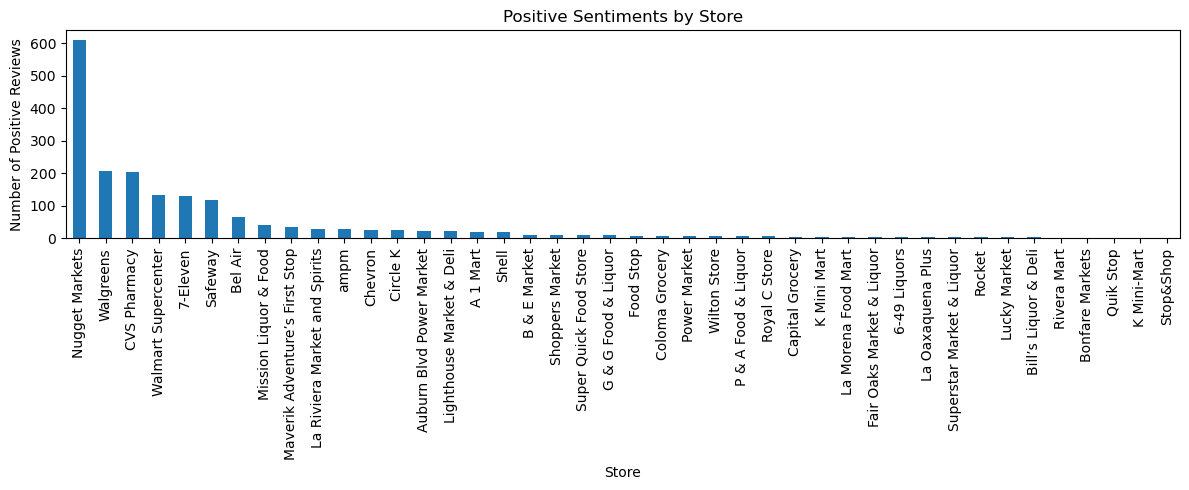

In [11]:
# Count positive sentiments by store
positive_counts = df[df['sentiment'] == 'positive']['biz_name'].value_counts()

# Get all unique store names
all_stores_pos = df['biz_name'].unique()

# Reindex to include all stores (fill missing with 0)
positive_counts = positive_counts.reindex(all_stores_pos, fill_value=0)
positive_counts = positive_counts.sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 5))
positive_counts.plot(kind='bar')
plt.xlabel('Store')
plt.ylabel('Number of Positive Reviews')
plt.title('Positive Sentiments by Store')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Negative Sentiments Bar Chart

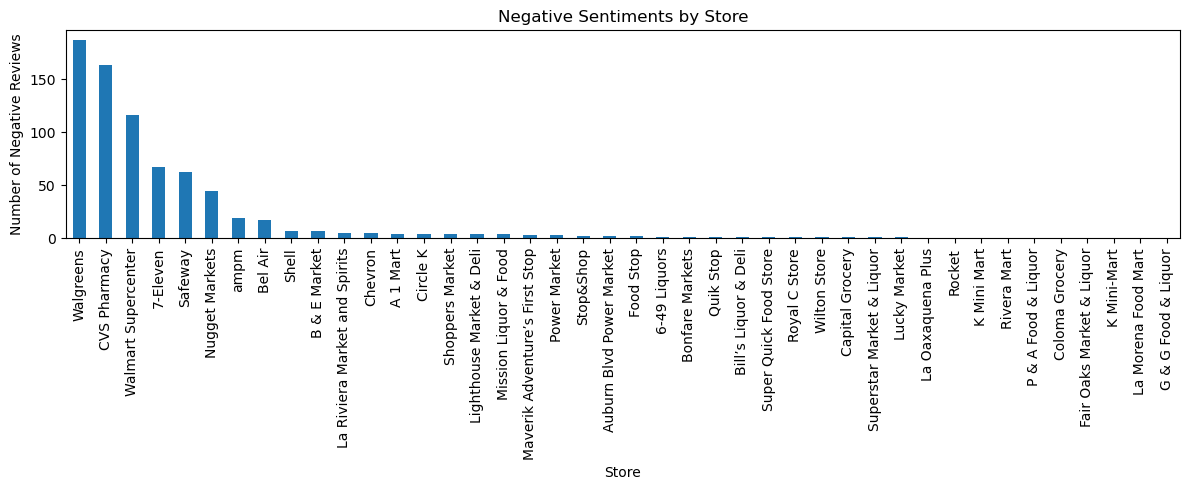

In [12]:
# Count negative sentiments by store
negative_counts = df[df['sentiment'] == 'negative']['biz_name'].value_counts()

# Get all unique store names
all_stores_neg = df['biz_name'].unique()

# Reindex to include all stores (fill missing with 0)
negative_counts = negative_counts.reindex(all_stores_neg, fill_value=0)
negative_counts = negative_counts.sort_values(ascending=False)
# Plot
plt.figure(figsize=(12, 5))
negative_counts.plot(kind='bar')
plt.xlabel('Store')
plt.ylabel('Number of Negative Reviews')
plt.title('Negative Sentiments by Store')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Neutral Sentiments Bar Chart

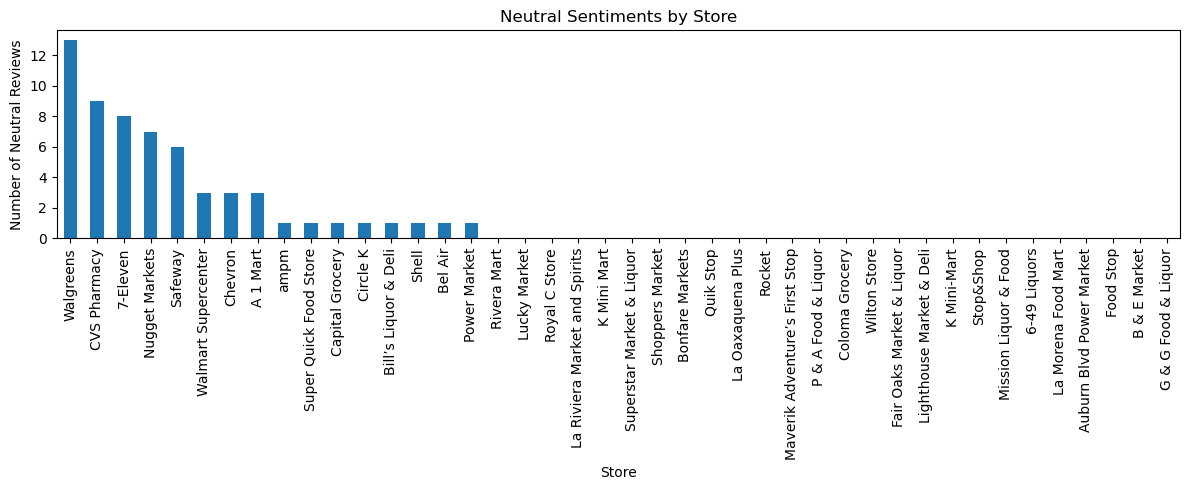

In [13]:
# Count neutral sentiments by store
neutral_counts = df[df['sentiment'] == 'neutral']['biz_name'].value_counts()

# Get all unique store names
all_stores_neu = df['biz_name'].unique()

# Reindex to include all stores (fill missing with 0)
neutral_counts = neutral_counts.reindex(all_stores_neu, fill_value=0)
neutral_counts = neutral_counts.sort_values(ascending=False)
# Plot
plt.figure(figsize=(12, 5))
neutral_counts.plot(kind='bar')
plt.xlabel('Store')
plt.ylabel('Number of Neutral Reviews')
plt.title('Neutral Sentiments by Store')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## TFIDF Matrix

### Construct TFIDF Matrix

In [11]:
class LemmaTokenizer(object):
    def __init__(self):
        self.stemmer = EnglishStemmer()
        self.stopWords = set(ENGLISH_STOP_WORDS)
    def __call__(self, doc):
        return [self.stemmer.stem(t) for t in word_tokenize(doc) 
                if t.isalpha() and t not in self.stopWords]


In [12]:
count_vect = CountVectorizer(
    lowercase=True,
    max_df=0.1,     # Remove words that appear in more than 10% of documents or 6000 documents
    min_df=0.001,   # Remove words that appear in less than 0.1% of documents or 60 documents
    ngram_range=(1,1), # default "unigrams"
    tokenizer=LemmaTokenizer()
)

In [13]:
tfidfTransformer = TfidfTransformer(smooth_idf=True, norm=None)
# https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html
counts = count_vect.fit_transform(reviews['text'])
tfidf = tfidfTransformer.fit_transform(counts)
printTermDocumentMatrix(count_vect, tfidf)

C:\Users\marvi\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


            S1   S2   S3   S4   S5   S6   S7   S8   S9  S10  ...  S2652  \
aback      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
abandon    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
abil       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
abl        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
abrupt     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
...        ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...   
yum        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
yummi      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
z          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
zero       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   
zinfandel  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0   

           S2653  S2654  S2655  S2656  S2657  S2658  S2659  S2660  S2661  
aback        0.0    0.0 

### Split Data Into Training and Validation Sets

In [14]:
# Split data into training and validation sets (60/40)
train_X, valid_X, train_y, valid_y = train_test_split(tfidf, reviews['rating'], test_size=0.4, random_state=1)

In [15]:
# Standardized Training and Validation Sets
scaler = StandardScaler(with_mean=False)
train_X_standardized = scaler.fit_transform(train_X)
valid_X_standardized = scaler.transform(valid_X)

## Lasso Regression Model

In [29]:
lasso_cv = LassoCV(max_iter=10000, alphas=np.logspace(-3, 3, 100), random_state=1, cv=5, n_jobs = -1)
lasso_cv.fit(train_X_standardized, train_y)

LassoCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5, max_iter=10000, n_jobs=-1, random_state=1)

In [30]:
print('Lasso-CV chosen regularization: ', lasso_cv.alpha_)

Lasso-CV chosen regularization:  0.037649358067924674


In [16]:
lasso_cv2 = Lasso(max_iter=10000, random_state=1, alpha = 0.037649358067924674)
lasso_cv2.fit(train_X_standardized, train_y)

Lasso(alpha=0.037649358067924674, max_iter=10000, random_state=1)

### Performance Metrics

In [11]:
# Lasso RMSE and Regularization Parameter
print('Training Data RMSE:')
print('')
regressionSummary(train_y, lasso_cv2.predict(train_X_standardized))
print('')
print('Validation Data RMSE:')
print('')
regressionSummary(valid_y, lasso_cv2.predict(valid_X_standardized))
print(lasso_cv2.coef_)

Training Data RMSE:


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1.0158
            Mean Absolute Error (MAE) : 0.8603
          Mean Percentage Error (MPE) : -27.3320
Mean Absolute Percentage Error (MAPE) : 49.2064

Validation Data RMSE:


Regression statistics

                      Mean Error (ME) : 0.0432
       Root Mean Squared Error (RMSE) : 1.3703
            Mean Absolute Error (MAE) : 1.1487
          Mean Percentage Error (MPE) : -32.9998
Mean Absolute Percentage Error (MAPE) : 67.3082
[-0.         -0.          0.01312873 ...  0.         -0.08277256
 -0.        ]


In [12]:
# Training and Validation R-Squared
from sklearn.metrics import r2_score
print('Training R-Squared:', r2_score(train_y, lasso_cv2.predict(train_X_standardized)))
print('Validation R-Squared:', r2_score(valid_y, lasso_cv2.predict(valid_X_standardized)))

Training R-Squared: 0.6612089639027594
Validation R-Squared: 0.3956881740537208


In [13]:
# Number of nonzero coefficients
coefficients = lasso_cv2.coef_
non_zero_count = np.count_nonzero(coefficients)
print(f"Number of non-zero coefficients selected by Lasso: {non_zero_count}")

Number of non-zero coefficients selected by Lasso: 397


### Gains and Lift Charts

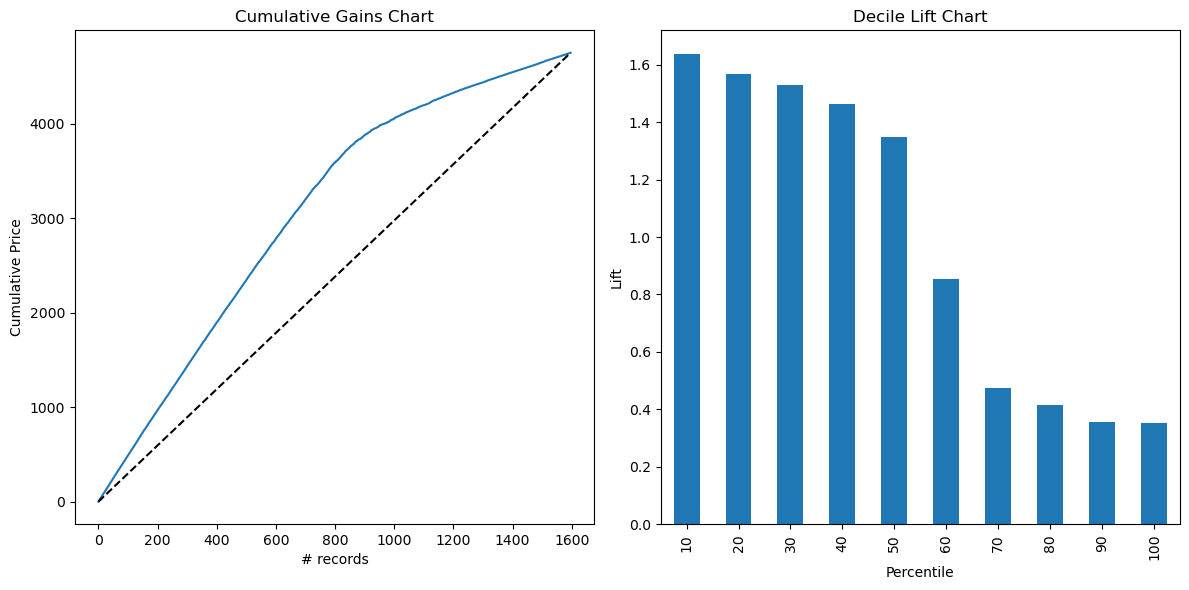

In [14]:
# Training Data

# sort the actual values in descending order of the prediction
df = pd.DataFrame({
    'predicted': lasso_cv2.predict(train_X_standardized),
    'actual': train_y, 
})
df = df.sort_values(by=['predicted'], ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = gainsChart(df['actual'], ax=axes[0])
ax.set_ylabel('Cumulative Price')
ax.set_title('Cumulative Gains Chart')

ax = liftChart(df['actual'], ax=axes[1], labelBars=False)
ax.set_ylabel('Lift')

plt.tight_layout()
plt.show()

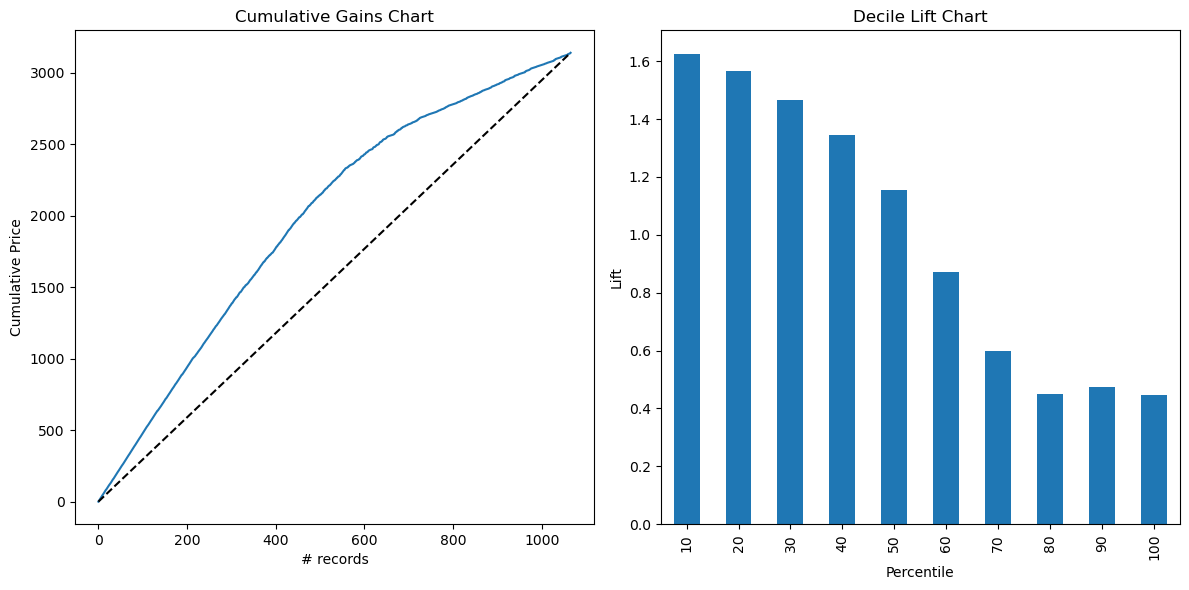

In [15]:
# Validation Data

# sort the actual values in descending order of the prediction
df = pd.DataFrame({
    'predicted': lasso_cv2.predict(valid_X_standardized),
    'actual': valid_y, 
})
df = df.sort_values(by=['predicted'], ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = gainsChart(df['actual'], ax=axes[0])
ax.set_ylabel('Cumulative Price')
ax.set_title('Cumulative Gains Chart')

ax = liftChart(df['actual'], ax=axes[1], labelBars=False)
ax.set_ylabel('Lift')

plt.tight_layout()
plt.show()

## Ridge Regression Model

In [37]:
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_cv.fit(train_X_standardized, train_y)

RidgeCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5)

In [38]:
print('Ridge-CV chosen regularization: ', ridge_cv.alpha_)

Ridge-CV chosen regularization:  1000.0


In [16]:
ridge_cv2 = Ridge(max_iter=10000,random_state=1, alpha = 1000.0)
ridge_cv2.fit(train_X_standardized, train_y)

Ridge(alpha=1000.0, max_iter=10000, random_state=1)

In [18]:
# Ridge RMSE and Regularization Parameter
print('Training Data RMSE:')
print('')
regressionSummary(train_y, ridge_cv2.predict(train_X_standardized))
print('')
print('Validation Data RMSE:')
print('')
regressionSummary(valid_y, ridge_cv2.predict(valid_X_standardized))
print(ridge_cv2.coef_)

Training Data RMSE:


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 0.6933
            Mean Absolute Error (MAE) : 0.5215
          Mean Percentage Error (MPE) : -16.8477
Mean Absolute Percentage Error (MAPE) : 29.3816

Validation Data RMSE:


Regression statistics

                      Mean Error (ME) : 0.0531
       Root Mean Squared Error (RMSE) : 1.5292
            Mean Absolute Error (MAE) : 1.1829
          Mean Percentage Error (MPE) : -26.9058
Mean Absolute Percentage Error (MAPE) : 69.6160
[-0.00999203 -0.01192337  0.01759694 ...  0.00993711 -0.04049522
 -0.00191891]


In [19]:
# Training and Validation R-Squared
from sklearn.metrics import r2_score
print('Training R-Squared:', r2_score(train_y, ridge_cv2.predict(train_X_standardized)))
print('Validation R-Squared:', r2_score(valid_y, ridge_cv2.predict(valid_X_standardized)))

Training R-Squared: 0.8421772236977925
Validation R-Squared: 0.2474441870042713


In [22]:
# Number of nonzero coefficients
coefficients = ridge_cv2.coef_
non_zero_count_ridge = np.count_nonzero(coefficients)
print(f"Number of non-zero coefficients selected by Ridge: {non_zero_count_ridge}")

Number of non-zero coefficients selected by Ridge: 2787


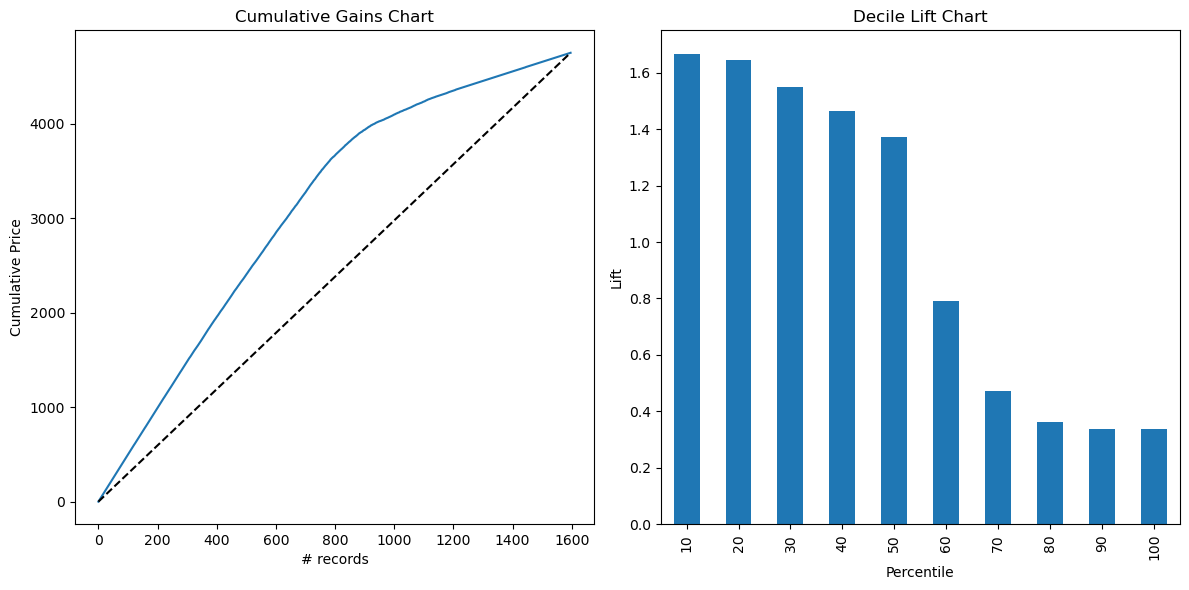

In [23]:
# Training Data

# sort the actual values in descending order of the prediction
df = pd.DataFrame({
    'predicted': ridge_cv2.predict(train_X_standardized),
    'actual': train_y, 
})
df = df.sort_values(by=['predicted'], ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = gainsChart(df['actual'], ax=axes[0])
ax.set_ylabel('Cumulative Price')
ax.set_title('Cumulative Gains Chart')

ax = liftChart(df['actual'], ax=axes[1], labelBars=False)
ax.set_ylabel('Lift')

plt.tight_layout()
plt.show()

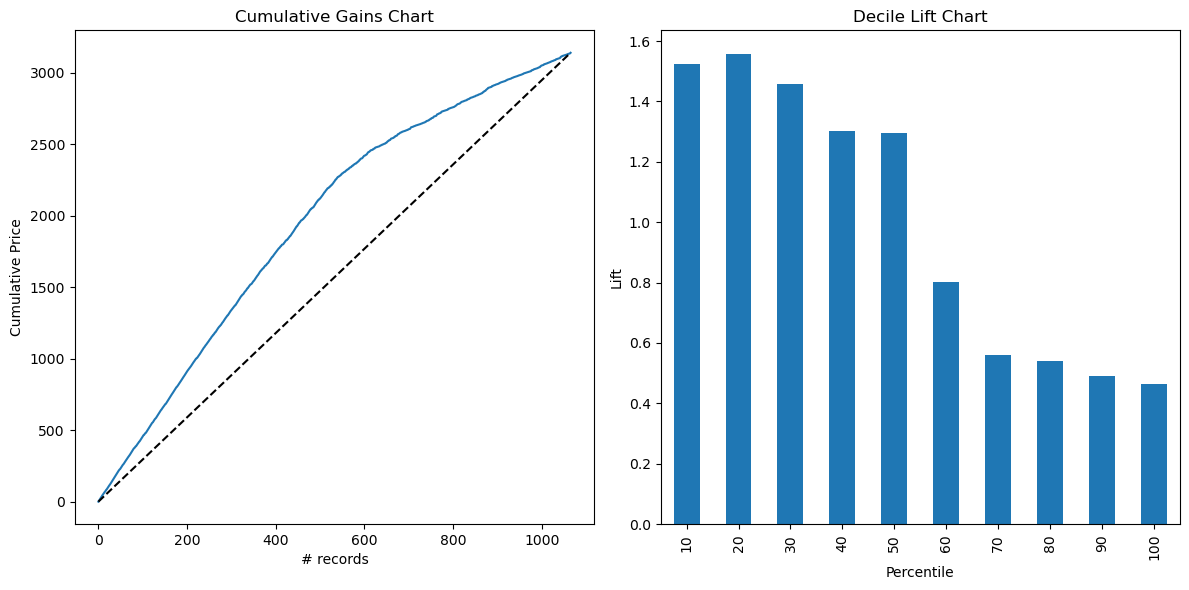

In [24]:
# Validation Data

# sort the actual values in descending order of the prediction
df = pd.DataFrame({
    'predicted': ridge_cv2.predict(valid_X_standardized),
    'actual': valid_y, 
})
df = df.sort_values(by=['predicted'], ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = gainsChart(df['actual'], ax=axes[0])
ax.set_ylabel('Cumulative Price')
ax.set_title('Cumulative Gains Chart')

ax = liftChart(df['actual'], ax=axes[1], labelBars=False)
ax.set_ylabel('Lift')

plt.tight_layout()
plt.show()

## Elastic Net Regression Model

In [25]:
# Standardized Training and Validation Sets
scaler = StandardScaler(with_mean=False)
train_X_standardized = scaler.fit_transform(train_X)
valid_X_standardized = scaler.transform(valid_X)



In [16]:
elasticnet_cv = ElasticNetCV(
    l1_ratio=np.arange(0.1, 0.95, 0.05),  # Elastic Net mixing ratio
    alphas=np.logspace(-3, 3, 100),                          # let sklearn choose a grid (or provide your own)
    cv=5,
    max_iter=10000,
    random_state=1,
    n_jobs = -1
)
elasticnet_cv.fit(train_X_standardized, train_y)

ElasticNetCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.873817...
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
             cv=5,
             l1_ratio=array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
       0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 ]),
             max_iter=10000, n_jobs=-1, random_state=1)

In [17]:
print('ElasticNet-CV chosen regularization: ', elasticnet_cv.alpha_)

ElasticNet-CV chosen regularization:  0.23101297000831603


In [26]:
elasticnet_cv2 = ElasticNet(max_iter=10000,random_state=1, alpha = 0.23101297000831603)
elasticnet_cv2.fit(train_X_standardized, train_y)

ElasticNet(alpha=0.23101297000831603, max_iter=10000, random_state=1)

In [27]:
# Elastic Net RMSE and Regularization Parameter
print('Training Data RMSE:')
print('')
regressionSummary(train_y, elasticnet_cv2.predict(train_X_standardized))
print('')
print('Validation Data RMSE:')
print('')
regressionSummary(valid_y, elasticnet_cv2.predict(valid_X_standardized))
print('Coefficients: \n',elasticnet_cv2.coef_)

Training Data RMSE:


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1.3766
            Mean Absolute Error (MAE) : 1.2329
          Mean Percentage Error (MPE) : -44.7908
Mean Absolute Percentage Error (MAPE) : 71.4988

Validation Data RMSE:


Regression statistics

                      Mean Error (ME) : -0.0172
       Root Mean Squared Error (RMSE) : 1.4667
            Mean Absolute Error (MAE) : 1.3213
          Mean Percentage Error (MPE) : -49.3435
Mean Absolute Percentage Error (MAPE) : 77.2718
Coefficients: 
 [-0.         -0.          0.         ...  0.         -0.04500816
 -0.        ]


In [28]:
# Training and Validation R-Squared
from sklearn.metrics import r2_score
print('Training R-Squared:', r2_score(train_y, elasticnet_cv2.predict(train_X_standardized)))
print('Validation R-Squared:', r2_score(valid_y, elasticnet_cv2.predict(valid_X_standardized)))

Training R-Squared: 0.37780100297215646
Validation R-Squared: 0.3076683323802635


In [29]:
# Number of nonzero coefficients
coefficients = elasticnet_cv2.coef_
non_zero_count_elasticnet = np.count_nonzero(coefficients)
print(f"Number of non-zero coefficients selected by Elastic Net: {non_zero_count_elasticnet}")

Number of non-zero coefficients selected by Elastic Net: 85


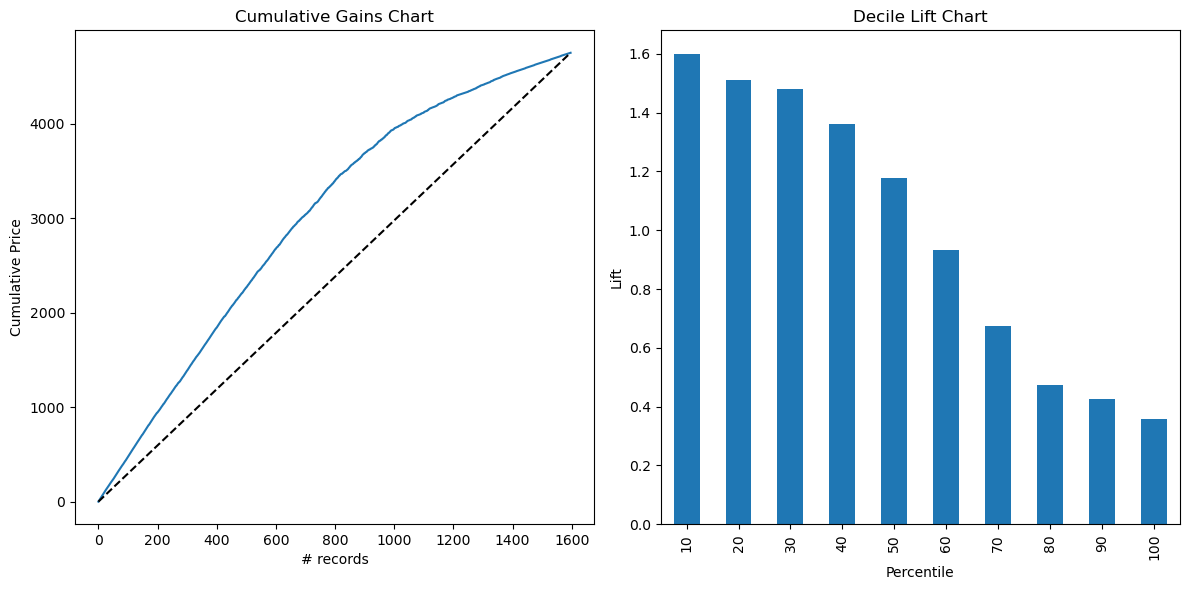

In [30]:
# Training Data

# sort the actual values in descending order of the prediction
df = pd.DataFrame({
    'predicted': elasticnet_cv2.predict(train_X_standardized),
    'actual': train_y, 
})
df = df.sort_values(by=['predicted'], ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = gainsChart(df['actual'], ax=axes[0])
ax.set_ylabel('Cumulative Price')
ax.set_title('Cumulative Gains Chart')

ax = liftChart(df['actual'], ax=axes[1], labelBars=False)
ax.set_ylabel('Lift')

plt.tight_layout()
plt.show()

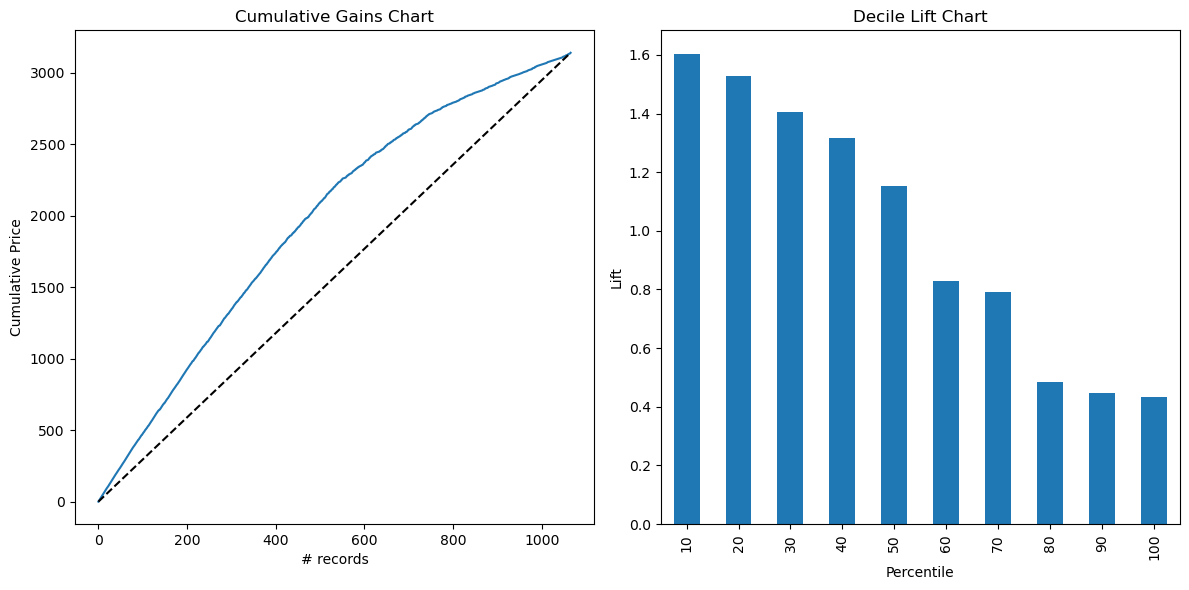

In [31]:
# Validation Data

# sort the actual values in descending order of the prediction
df = pd.DataFrame({
    'predicted': elasticnet_cv2.predict(valid_X_standardized),
    'actual': valid_y, 
})
df = df.sort_values(by=['predicted'], ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = gainsChart(df['actual'], ax=axes[0])
ax.set_ylabel('Cumulative Price')
ax.set_title('Cumulative Gains Chart')

ax = liftChart(df['actual'], ax=axes[1], labelBars=False)
ax.set_ylabel('Lift')

plt.tight_layout()
plt.show()

## Sample Prediction Analysis

### Training Set Predictions

In [18]:
train_set_pred = lasso_cv2.predict(train_X_standardized)
train_col = pd.Series(train_set_pred)
train_col

0       3.656657
1       2.474177
2       3.044168
3       1.181118
4       2.706911
          ...   
1591    2.643682
1592    4.559437
1593    4.261974
1594    3.168496
1595    0.095573
Length: 1596, dtype: float64

### Validation Set Predictions

In [19]:
valid_set_pred = lasso_cv2.predict(valid_X_standardized)
valid_col = pd.Series(valid_set_pred)
valid_col

0       3.700999
1       4.372116
2       4.878890
3       1.718366
4       3.547505
          ...   
1060    3.852303
1061    4.394347
1062    2.218575
1063    1.777387
1064    1.703211
Length: 1065, dtype: float64

### Merge Training and Validation Set Predictions

In [20]:
merged_set_pred = pd.concat([train_col,valid_col])
merged_set_pred = merged_set_pred.to_numpy()
merged_set_pred

array([3.6566569 , 2.47417672, 3.04416842, ..., 2.21857489, 1.777387  ,
       1.70321055])

In [21]:
merged_df = pd.DataFrame({
    "Business Name": reviews['biz_name'],
    "Text": reviews['text'],
    "Predicted Rating": merged_set_pred
})
merged_df

,Business Name,Text,Predicted Rating
0,Rocket,I absolutely love Anuk and his staff here! The...,3.656657
1,Rocket,"Convenient location, very clean and well kept ...",2.474177
2,Rocket,"Good location, lots of space in parking lot an...",3.044168
3,Wilton Store,Dishonest clerk charged me 6 dollars extra for...,1.181118
4,Wilton Store,They close at ten but the new girl turns off t...,2.706911
...,...,...,...
2656,Walmart Supercenter,BYOB... bring your own bag or buy theirs. That...,3.852303
2657,Walmart Supercenter,"I'm usually a hardcore Target girl, but every ...",4.394347
2658,Walmart Supercenter,WHAT!!!!!!!!!!!!!!!! YOU DONT HAVE BAGS!!!!!!!...,2.218575
2659,Walmart Supercenter,While I am usually a fan of Wal-Mart given the...,1.777387


### Convenience Store Grouped Median Ratings (Top 5)

In [22]:
ave_rat_by_store = merged_df.groupby('Business Name')['Predicted Rating'].median()
ave_rat_by_store = pd.DataFrame(ave_rat_by_store)
ave_rat_by_store = ave_rat_by_store.sort_values(by = 'Predicted Rating',ascending = False)
ave_rat_by_store.head(5)

,Predicted Rating
Business Name,
Royal C Store,3.724797
Super Quick Food Store,3.693426
Capital Grocery,3.625353
P & A Food & Liquor,3.577738
G & G Food & Liquor,3.556830


### Convenience Store Grouped Median Ratings (Bottom 5)

In [24]:
ave_rat_by_store2 = merged_df.groupby('Business Name')['Predicted Rating'].median()
ave_rat_by_store2 = pd.DataFrame(ave_rat_by_store)
ave_rat_by_store2 = ave_rat_by_store2.sort_values(by = 'Predicted Rating',ascending = True)
ave_rat_by_store2.head(5)

,Predicted Rating
Business Name,
Quik Stop,0.970417
Superstar Market & Liquor,1.453046
Coloma Grocery,1.762866
K Mini-Mart,1.917903
Wilton Store,1.992789


<center>END</center>